#Part 1: Multilayer Perceptron

In this part, I use Multilayer Perceptron models for tabular data.

I have two tasks:

1. Binary Classification  
Target: `loan_status`

2. Regression  
Target: `loan_amnt`

The datasets are already cleaned, encoded, and feature-engineered.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras import callbacks
from tensorflow.keras import initializers
from tensorflow.keras.regularizers import l1_l2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
CLASS_DATA_URL = "https://raw.githubusercontent.com/salehmh10/ADS/main/Assignment3/classification_DATA.csv"
REG_DATA_URL = "https://raw.githubusercontent.com/salehmh10/ADS/main/Assignment3/regression_DATA.csv"

def test_and_load_csv(url, dataset_name):
    response = requests.get(url)

    print("=" * 60)
    print(dataset_name)
    print("Status code:", response.status_code)
    print("File size:", len(response.text))
    print("First characters:")
    print(response.text[:200])

    if response.status_code != 200:
        raise ValueError(f"{dataset_name} was not found.")

    if len(response.text.strip()) == 0:
        raise ValueError(f"{dataset_name} is empty.")

    df = pd.read_csv(url)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    print("\nLoaded successfully.")
    print("Shape:", df.shape)
    display(df.head())

    return df

classification_df = test_and_load_csv(CLASS_DATA_URL, "Classification Dataset")
regression_df = test_and_load_csv(REG_DATA_URL, "Regression Dataset")

Classification Dataset
Status code: 200
File size: 9697136
First characters:
person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_Associate,pers

Loaded successfully.
Shape: (44993, 38)


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,interest_per_credit_score,default_interest_interaction,high_loan_burden,high_interest_rate,annual_interest_amount,young_applicant,low_income_applicant,high_income_applicant,short_credit_history,loan_status
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,...,0.028556,0.00,1,1,5607.00,1,0,0,0,1
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,...,0.022103,11.14,0,0,111.40,1,1,0,1,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,...,0.020268,0.00,1,0,707.85,0,1,0,0,1
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,...,0.022563,0.00,1,1,5330.50,1,0,0,1,1
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,0,...,0.024352,0.00,1,1,4994.50,1,0,0,0,1


Regression Dataset
Status code: 200
File size: 14152231
First characters:
person_age,person_gender,person_income,person_emp_exp,loan_int_rate,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_Associate,person_education_Bachelor,person_e

Loaded successfully.
Shape: (44993, 40)


,person_age,person_gender,person_income,person_emp_exp,loan_int_rate,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_Associate,person_education_Bachelor,...,income_credit_history_capacity,employment_stability_ratio,income_employment_capacity,credit_history_age_ratio,credit_start_age,log_credit_strength,home_ownership_income_capacity,education_income_capacity,intent_income_capacity,loan_amnt
0,22.0,0,71948.0,0,16.02,3.0,561,0,0,0,...,15.503918,0.000000,7.751959,0.136364,19.0,7.428927,11.183713,15.098012,11.183713,35000.0
1,21.0,0,12282.0,0,11.14,2.0,504,1,0,0,...,10.344502,0.000000,6.526654,0.095238,19.0,6.916715,15.065554,9.415971,10.357569,1000.0
2,25.0,0,12438.0,3,12.87,3.0,635,0,0,0,...,13.070804,0.428571,15.174733,0.120000,22.0,7.552762,12.728599,9.428592,9.900022,5500.0
3,23.0,0,79753.0,0,15.23,2.0,675,0,0,1,...,12.399710,0.000000,7.823346,0.086957,21.0,7.208600,11.286702,14.108378,11.851037,35000.0
4,24.0,1,66135.0,1,14.27,4.0,586,0,0,0,...,17.863905,0.166667,12.194012,0.166667,20.0,7.760041,11.099469,14.984282,11.654442,35000.0


##Dataset Overview

Before training the neural networks, I check the data shape, missing values, target columns, and feature types.
This helps me make sure the data is ready for MLP models.

In [ ]:
CLASS_TARGET = "loan_status"
REG_TARGET = "loan_amnt"

print("Classification Dataset Info")
print("Shape:", classification_df.shape)
print("Missing values:", classification_df.isnull().sum().sum())
print("Non-numeric columns:")
print(classification_df.select_dtypes(exclude=[np.number]).columns.tolist())

print("\nClassification target values:")
print(classification_df[CLASS_TARGET].value_counts())
print("\nClassification target ratio:")
print(classification_df[CLASS_TARGET].value_counts(normalize=True).round(3))

print("\n" + "=" * 60)

print("Regression Dataset Info")
print("Shape:", regression_df.shape)
print("Missing values:", regression_df.isnull().sum().sum())
print("Non-numeric columns:")
print(regression_df.select_dtypes(exclude=[np.number]).columns.tolist())

print("\nRegression target summary:")
display(regression_df[REG_TARGET].describe())

Classification Dataset Info
Shape: (44993, 38)
Missing values: 0
Non-numeric columns:
[]

Classification target values:
loan_status
0    34993
1    10000
Name: count, dtype: int64

Classification target ratio:
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64

Regression Dataset Info
Shape: (44993, 40)
Missing values: 0
Non-numeric columns:
[]

Regression target summary:


,loan_amnt
count,44993.000000
mean,9583.176761
std,6314.802655
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12237.000000
max,35000.000000


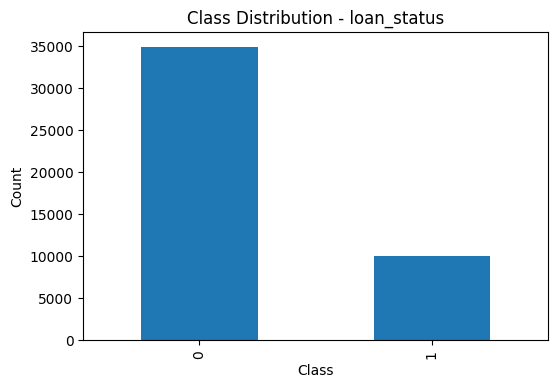

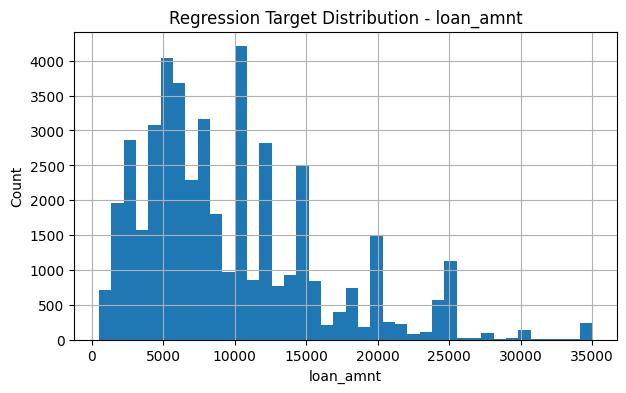

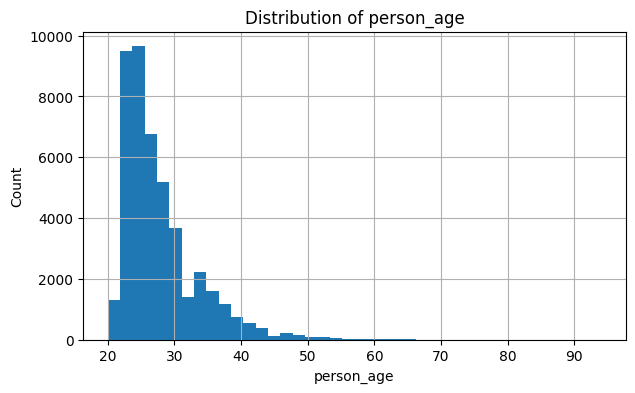

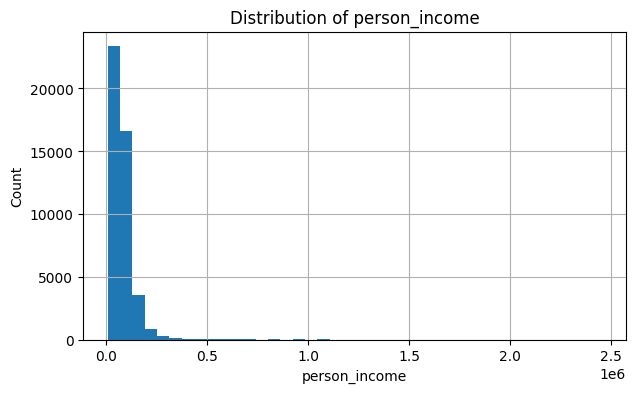

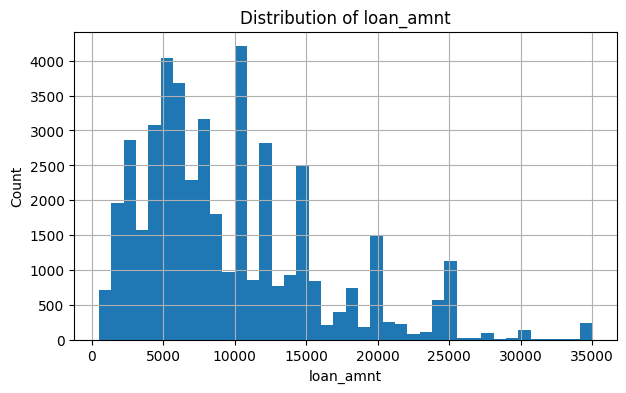

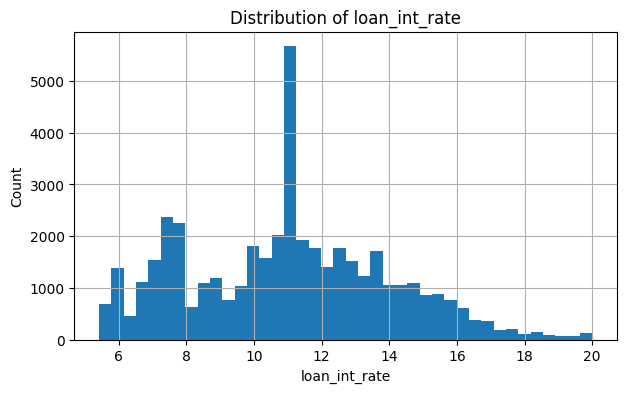

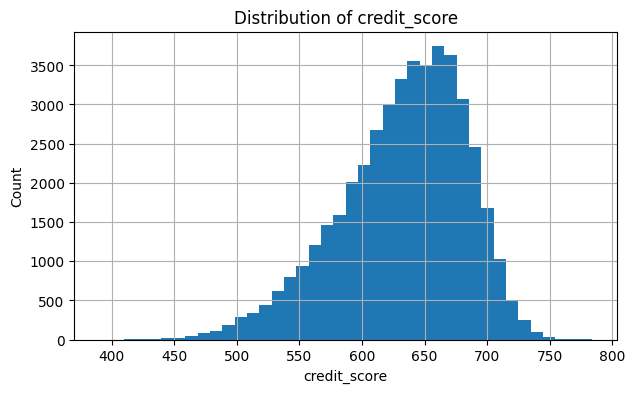

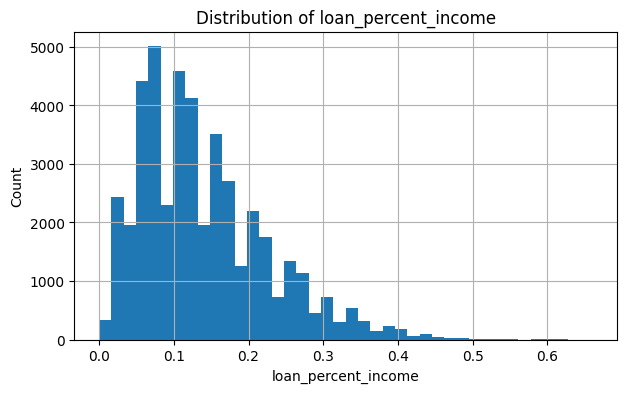

In [ ]:
plt.figure(figsize=(6, 4))
classification_df[CLASS_TARGET].value_counts().plot(kind="bar")
plt.title("Class Distribution - loan_status")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
regression_df[REG_TARGET].hist(bins=40)
plt.title("Regression Target Distribution - loan_amnt")
plt.xlabel("loan_amnt")
plt.ylabel("Count")
plt.show()

important_cols_cls = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "credit_score",
    "loan_percent_income"
]

for col in important_cols_cls:
    if col in classification_df.columns:
        plt.figure(figsize=(7, 4))
        classification_df[col].hist(bins=40)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

## Prepare Features and Targets

Now I separate the input features from the target columns.

For classification, the target is `loan_status`.  
For regression, the target is `loan_amnt`.

The target column must not stay inside the input features.

In [ ]:
X_cls = classification_df.drop(columns=[CLASS_TARGET])
y_cls = classification_df[CLASS_TARGET].astype(int)

X_reg = regression_df.drop(columns=[REG_TARGET])
y_reg = regression_df[REG_TARGET].astype(float)

print("Classification X shape:", X_cls.shape)
print("Classification y shape:", y_cls.shape)

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

Classification X shape: (44993, 37)
Classification y shape: (44993,)
Regression X shape: (44993, 39)
Regression y shape: (44993,)


In [ ]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.25,
    random_state=42,
    stratify=y_cls
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

print("Classification train shape:", X_train_cls.shape)
print("Classification test shape:", X_test_cls.shape)

print("Regression train shape:", X_train_reg.shape)
print("Regression test shape:", X_test_reg.shape)

print("\nClassification train class ratio:")
print(y_train_cls.value_counts(normalize=True).round(3))

print("\nClassification test class ratio:")
print(y_test_cls.value_counts(normalize=True).round(3))

Classification train shape: (33744, 37)
Classification test shape: (11249, 37)
Regression train shape: (33744, 39)
Regression test shape: (11249, 39)

Classification train class ratio:
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64

Classification test class ratio:
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


## Standardization

In [ ]:
def scale_continuous_features(X_train, X_test):
    binary_features = [
        col for col in X_train.columns
        if X_train[col].nunique() <= 2
    ]

    continuous_features = [
        col for col in X_train.columns
        if col not in binary_features
    ]

    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[continuous_features] = scaler.fit_transform(
        X_train[continuous_features]
    )

    X_test_scaled[continuous_features] = scaler.transform(
        X_test[continuous_features]
    )

    X_train_scaled = X_train_scaled.astype("float32")
    X_test_scaled = X_test_scaled.astype("float32")

    return X_train_scaled, X_test_scaled, binary_features, continuous_features, scaler

X_train_cls_scaled, X_test_cls_scaled, binary_cls, continuous_cls, scaler_cls = scale_continuous_features(
    X_train_cls,
    X_test_cls
)

X_train_reg_scaled, X_test_reg_scaled, binary_reg, continuous_reg, scaler_reg = scale_continuous_features(
    X_train_reg,
    X_test_reg
)

y_train_cls = y_train_cls.astype("float32")
y_test_cls = y_test_cls.astype("float32")

y_train_reg = y_train_reg.astype("float32")
y_test_reg = y_test_reg.astype("float32")

print("Classification binary features:", len(binary_cls))
print("Classification continuous features:", len(continuous_cls))

print("Regression binary features:", len(binary_reg))
print("Regression continuous features:", len(continuous_reg))

Classification binary features: 20
Classification continuous features: 17
Regression binary features: 18
Regression continuous features: 21


In [ ]:
print("Classification scaled data:")
display(X_train_cls_scaled.head())

print("Regression scaled data:")
display(X_train_reg_scaled.head())

print("Classification train mean sample:")
display(X_train_cls_scaled[continuous_cls].mean().head())

print("Regression train mean sample:")
display(X_train_reg_scaled[continuous_reg].mean().head())

Classification scaled data:


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,employment_experience_ratio,interest_per_credit_score,default_interest_interaction,high_loan_burden,high_interest_rate,annual_interest_amount,young_applicant,low_income_applicant,high_income_applicant,short_credit_history
41179,1.902416,0.0,1.563976,1.788128,0.387476,0.025877,-0.797691,2.871131,0.921696,1.0,...,1.067280,-0.239369,1.036014,0.0,0.0,0.293794,0.0,0.0,1.0,0.0
4843,-0.296876,1.0,-0.561309,-0.236878,-0.725757,-0.212742,-0.337934,-0.484113,0.842158,0.0,...,0.205521,-0.431973,-0.951263,0.0,0.0,-0.659165,0.0,1.0,0.0,0.0
44296,-0.635228,0.0,0.006986,-0.574379,1.659741,1.124868,1.271215,-0.484113,-1.504204,0.0,...,-0.342871,1.665176,-0.951263,1.0,1.0,2.103608,1.0,0.0,0.0,0.0
1038,-0.296876,1.0,0.262727,-0.743129,1.341675,0.956826,0.581580,-0.742209,0.563776,1.0,...,-1.028361,0.695267,1.532833,1.0,1.0,1.660671,0.0,0.0,1.0,0.0
44886,-0.804404,0.0,-0.949632,-0.911880,-0.715738,0.143506,1.501094,-0.484113,-0.947440,0.0,...,-1.439655,0.410007,-0.951263,1.0,0.0,-0.588435,1.0,1.0,0.0,0.0


Regression scaled data:


,person_age,person_gender,person_income,person_emp_exp,loan_int_rate,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_Associate,person_education_Bachelor,...,income_credit_capacity,income_credit_history_capacity,employment_stability_ratio,income_employment_capacity,credit_history_age_ratio,credit_start_age,log_credit_strength,home_ownership_income_capacity,education_income_capacity,intent_income_capacity
27001,0.384140,0.0,1.016511,0.782979,-1.877394,0.811581,-1.660071,0.0,1.0,0.0,...,-0.763637,1.276254,1.309800,1.216118,1.137661,-0.283159,0.771579,1.156125,0.383875,0.130349
25126,1.062952,1.0,0.263640,1.290830,-0.126726,1.069937,1.378048,1.0,0.0,1.0,...,1.524218,1.304910,1.241299,1.399364,1.072176,0.684655,1.338140,0.936925,0.824936,-0.141398
38002,-0.803780,1.0,-0.110693,-0.909861,-1.678761,-0.480199,0.603625,0.0,1.0,0.0,...,0.576898,-0.336170,-1.430261,-1.340719,-0.265983,-0.928368,-0.232154,-0.795775,-0.124893,-0.332493
1039,-0.803780,1.0,0.286822,-0.571293,1.004475,-0.996910,-1.282788,1.0,1.0,0.0,...,-0.755526,-1.266757,-0.115031,-0.380493,-1.234012,-0.283159,-1.599280,-0.675484,0.096406,-0.483428
26136,0.384140,1.0,0.579301,-0.063441,1.004475,0.811581,0.305771,0.0,0.0,0.0,...,0.782942,1.191201,-0.060230,0.414872,1.137661,-0.283159,1.039037,1.039749,-0.902650,-0.013925


Classification train mean sample:


,0
person_age,-2.260963e-09
person_income,2.260963e-10
person_emp_exp,-9.722142e-09
loan_amnt,3.221873e-09
loan_int_rate,-5.539360e-09


Regression train mean sample:


,0
person_age,-5.200215e-09
person_income,-7.913372e-10
person_emp_exp,4.804547e-09
loan_int_rate,-2.713156e-09
cb_person_cred_hist_length,0.000000e+00


## MLP Model Functions

I use Keras to build MLP models.

The function below is similar to the idea in Lab 10.  
I can change hidden layers, activation function, optimizer, learning rate, dropout, regularization, batch normalization, and gradient clipping.

In [ ]:
def get_initializer(weight_initializer):
    if weight_initializer == "RandomNormal":
        return initializers.RandomNormal()
    elif weight_initializer == "RandomUniform":
        return initializers.RandomUniform()
    elif weight_initializer == "Zeros":
        return initializers.Zeros()
    elif weight_initializer == "GlorotUniform":
        return initializers.GlorotUniform()
    elif weight_initializer == "GlorotNormal":
        return initializers.GlorotNormal()
    elif weight_initializer == "HeNormal":
        return initializers.HeNormal()
    else:
        return None


def get_optimizer(optimizer_name, learning_rate, momentum=0.0, clipnorm=None):
    optimizer_params = {"learning_rate": learning_rate}

    if clipnorm is not None:
        optimizer_params["clipnorm"] = clipnorm

    if optimizer_name == "sgd":
        return tf.keras.optimizers.SGD(**optimizer_params)

    elif optimizer_name == "sgd_momentum":
        return tf.keras.optimizers.SGD(
            momentum=momentum,
            **optimizer_params
        )

    elif optimizer_name == "rmsprop":
        return tf.keras.optimizers.RMSprop(**optimizer_params)

    else:
        return tf.keras.optimizers.Adam(**optimizer_params)


def create_mlp_model(
    input_size,
    task="classification",
    no_hidden_neurons=[64, 32],
    activation_func="relu",
    learning_rate=0.001,
    optimizer_name="adam",
    momentum=0.0,
    dropout_rate=0.0,
    l1_reg=0.0,
    l2_reg=0.0,
    activity_l1_reg=0.0,
    activity_l2_reg=0.0,
    weight_initializer="GlorotUniform",
    use_batch_norm=False,
    clipnorm=None
):
    tf.keras.backend.clear_session()

    kernel_regularizer = None
    activity_regularizer = None

    if l1_reg > 0 or l2_reg > 0:
        kernel_regularizer = l1_l2(l1=l1_reg, l2=l2_reg)

    if activity_l1_reg > 0 or activity_l2_reg > 0:
        activity_regularizer = l1_l2(l1=activity_l1_reg, l2=activity_l2_reg)

    initializer = get_initializer(weight_initializer)

    model = Sequential()
    model.add(Input(shape=(input_size,)))

    for n_neurons in no_hidden_neurons:
        if activation_func == "leaky_relu":
            model.add(
                Dense(
                    n_neurons,
                    kernel_initializer=initializer,
                    kernel_regularizer=kernel_regularizer,
                    activity_regularizer=activity_regularizer
                )
            )
            model.add(LeakyReLU(negative_slope=0.01))
        else:
            model.add(
                Dense(
                    n_neurons,
                    activation=activation_func,
                    kernel_initializer=initializer,
                    kernel_regularizer=kernel_regularizer,
                    activity_regularizer=activity_regularizer
                )
            )

        if use_batch_norm:
            model.add(BatchNormalization())

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    if task == "classification":
        model.add(Dense(1, activation="sigmoid"))
        loss_function = "binary_crossentropy"
        metrics_list = [
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]

    else:
        model.add(Dense(1, activation="linear"))
        loss_function = "mse"
        metrics_list = ["mae"]

    optimizer = get_optimizer(
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        momentum=momentum,
        clipnorm=clipnorm
    )

    model.compile(
        loss=loss_function,
        optimizer=optimizer,
        metrics=metrics_list
    )

    return model

In [ ]:
def get_callbacks(use_scheduler=False):
    early_stopping = callbacks.EarlyStopping(
        min_delta=0.001,
        patience=5,
        restore_best_weights=True,
        monitor="val_loss"
    )

    callback_list = [early_stopping]

    if use_scheduler:
        lr_scheduler = callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=0.000001
        )
        callback_list.append(lr_scheduler)

    return callback_list


def plot_history(history, title="Model History"):
    hist_df = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 4))
    plt.plot(hist_df["loss"], label="Training Loss")
    plt.plot(hist_df["val_loss"], label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "accuracy" in hist_df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(hist_df["accuracy"], label="Training Accuracy")
        plt.plot(hist_df["val_accuracy"], label="Validation Accuracy")
        plt.title(title + " - Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

    if "mae" in hist_df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(hist_df["mae"], label="Training MAE")
        plt.plot(hist_df["val_mae"], label="Validation MAE")
        plt.title(title + " - MAE")
        plt.xlabel("Epochs")
        plt.ylabel("MAE")
        plt.legend()
        plt.show()

In [ ]:
def evaluate_classifier(model, X_test, y_test, threshold=0.5):
    probabilities = model.predict(X_test, verbose=0).ravel()
    predictions = (probabilities >= threshold).astype(int)

    result = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "macro_f1": f1_score(y_test, predictions, average="macro", zero_division=0)
    }

    return result, predictions, probabilities


def evaluate_regressor(model, X_test, y_test):
    predictions = model.predict(X_test, verbose=0).ravel()

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    result = {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

    return result, predictions

## Baseline MLP Classifier

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9194 - loss: 0.1781 - precision: 0.8497 - recall: 0.7739 - val_accuracy: 0.9148 - val_loss: 0.

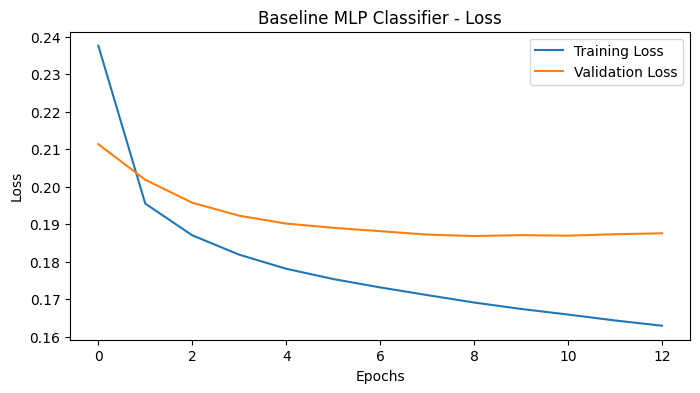

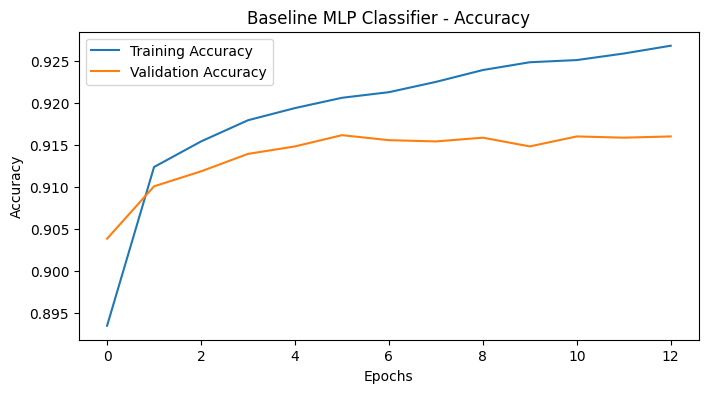

Baseline Classification Results
accuracy : 0.9179
precision : 0.8397
recall : 0.7792
f1 : 0.8083
macro_f1 : 0.878


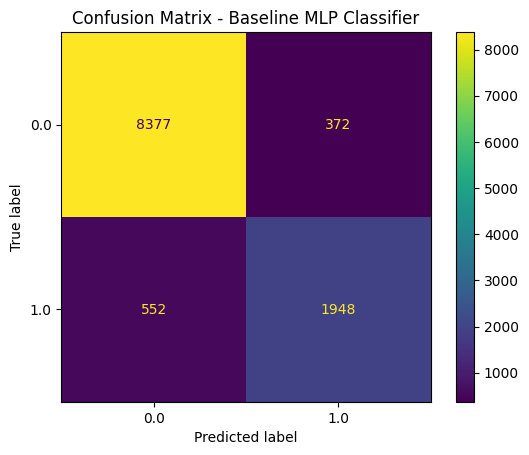

In [ ]:
tf.keras.utils.set_random_seed(42)

baseline_clf = create_mlp_model(
    input_size=X_train_cls_scaled.shape[1],
    task="classification",
    no_hidden_neurons=[64, 32],
    activation_func="relu",
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    l1_reg=0.0,
    l2_reg=0.0,
    weight_initializer="GlorotUniform"
)

baseline_clf.summary()

history_baseline_clf = baseline_clf.fit(
    X_train_cls_scaled,
    y_train_cls,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=get_callbacks(use_scheduler=False),
    verbose=1
)

plot_history(history_baseline_clf, "Baseline MLP Classifier")

baseline_clf_result, baseline_clf_pred, baseline_clf_prob = evaluate_classifier(
    baseline_clf,
    X_test_cls_scaled,
    y_test_cls
)

print("Baseline Classification Results")
for key, value in baseline_clf_result.items():
    print(key, ":", round(value, 4))

ConfusionMatrixDisplay.from_predictions(y_test_cls, baseline_clf_pred)
plt.title("Confusion Matrix - Baseline MLP Classifier")
plt.show()

## Baseline MLP Regressor

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31168810.0000 - mae: 4331.1602 - val_loss: 31475912.0000 - val_mae: 4328.6133
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━

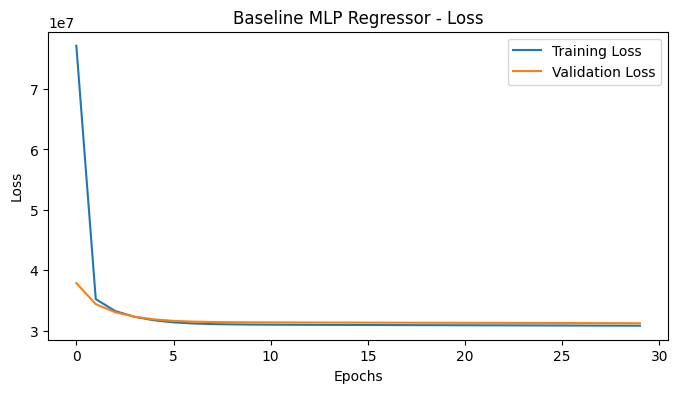

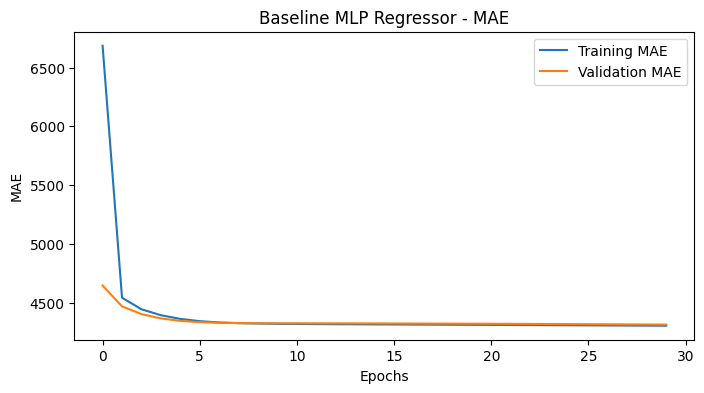

Baseline Regression Results
mae : 4338.3164
rmse : 5629.8163
r2 : 0.2279


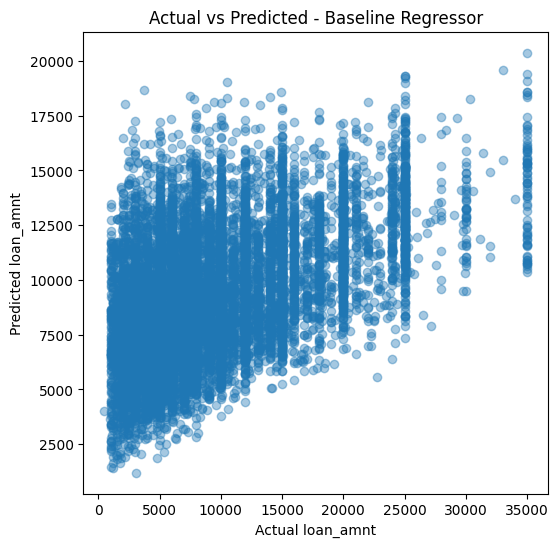

In [ ]:
tf.keras.utils.set_random_seed(42)

baseline_reg = create_mlp_model(
    input_size=X_train_reg_scaled.shape[1],
    task="regression",
    no_hidden_neurons=[64, 32],
    activation_func="relu",
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    l1_reg=0.0,
    l2_reg=0.0,
    weight_initializer="GlorotUniform"
)

baseline_reg.summary()

history_baseline_reg = baseline_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=get_callbacks(use_scheduler=False),
    verbose=1
)

plot_history(history_baseline_reg, "Baseline MLP Regressor")

baseline_reg_result, baseline_reg_pred = evaluate_regressor(
    baseline_reg,
    X_test_reg_scaled,
    y_test_reg
)

print("Baseline Regression Results")
for key, value in baseline_reg_result.items():
    print(key, ":", round(value, 4))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, baseline_reg_pred, alpha=0.4)
plt.xlabel("Actual loan_amnt")
plt.ylabel("Predicted loan_amnt")
plt.title("Actual vs Predicted - Baseline Regressor")
plt.show()

## Classification Experiments

In [ ]:
#Classification Experiment Functions
BASE_CLF_MODEL_PARAMS = {
    "no_hidden_neurons": [64, 32],
    "activation_func": "relu",
    "learning_rate": 0.001,
    "optimizer_name": "adam",
    "momentum": 0.0,
    "dropout_rate": 0.0,
    "l1_reg": 0.0,
    "l2_reg": 0.0,
    "activity_l1_reg": 0.0,
    "activity_l2_reg": 0.0,
    "weight_initializer": "GlorotUniform",
    "use_batch_norm": False,
    "clipnorm": None
}

BASE_TRAINING_PARAMS = {
    "epochs": 30,
    "batch_size": 32
}


def train_and_test_classifier(experiment):
    tf.keras.utils.set_random_seed(42)

    model_params = BASE_CLF_MODEL_PARAMS.copy()
    model_params.update(experiment.get("model_params", {}))

    training_params = BASE_TRAINING_PARAMS.copy()
    training_params.update(experiment.get("training_params", {}))

    model = create_mlp_model(
        input_size=X_train_cls_scaled.shape[1],
        task="classification",
        **model_params
    )

    history = model.fit(
        X_train_cls_scaled,
        y_train_cls,
        validation_split=0.2,
        callbacks=get_callbacks(use_scheduler=experiment.get("use_scheduler", False)),
        verbose=0,
        **training_params
    )

    result, predictions, probabilities = evaluate_classifier(
        model,
        X_test_cls_scaled,
        y_test_cls
    )

    result["group"] = experiment["group"]
    result["experiment"] = experiment["experiment"]
    result["min_val_loss"] = min(history.history["val_loss"])
    result["epochs_used"] = len(history.history["loss"])

    return model, history, result

### Experiment Helper

I use this helper function to run each experiment.

The model training is visible now.  
So I can see each epoch, training loss, validation loss, accuracy, precision, and recall.

In [ ]:
classification_result_tables = {}
classification_models = {}
classification_histories = {}

baseline_row = baseline_clf_result.copy()
baseline_row["group"] = "Baseline"
baseline_row["experiment"] = "Baseline"
baseline_row["min_val_loss"] = min(history_baseline_clf.history["val_loss"])
baseline_row["epochs_used"] = len(history_baseline_clf.history["loss"])

classification_result_tables["Baseline"] = pd.DataFrame([baseline_row])
classification_models[("Baseline", "Baseline")] = baseline_clf
classification_histories[("Baseline", "Baseline")] = history_baseline_clf


def get_experiment_callbacks(use_early_stopping=True, use_scheduler=False):
    callback_list = []

    if use_early_stopping:
        early_stopping = callbacks.EarlyStopping(
            monitor="val_loss",
            min_delta=0.001,
            patience=5,
            restore_best_weights=True
        )
        callback_list.append(early_stopping)

    if use_scheduler:
        lr_scheduler = callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=0.000001
        )
        callback_list.append(lr_scheduler)

    return callback_list


def train_and_test_classifier_visible(experiment, group_name, default_epochs=10):
    tf.keras.utils.set_random_seed(42)

    model_params = BASE_CLF_MODEL_PARAMS.copy()
    model_params.update(experiment.get("model_params", {}))

    training_params = {
        "epochs": default_epochs,
        "batch_size": 32
    }
    training_params.update(experiment.get("training_params", {}))

    print("\n" + "=" * 80)
    print("Group:", group_name)
    print("Experiment:", experiment["experiment"])
    print("Epochs:", training_params["epochs"])
    print("Batch size:", training_params["batch_size"])
    print("=" * 80)

    model = create_mlp_model(
        input_size=X_train_cls_scaled.shape[1],
        task="classification",
        **model_params
    )

    history = model.fit(
        X_train_cls_scaled,
        y_train_cls,
        validation_split=0.2,
        callbacks=get_experiment_callbacks(
            use_early_stopping=experiment.get("use_early_stopping", True),
            use_scheduler=experiment.get("use_scheduler", False)
        ),
        verbose=1,
        **training_params
    )

    result, predictions, probabilities = evaluate_classifier(
        model,
        X_test_cls_scaled,
        y_test_cls
    )

    result["group"] = group_name
    result["experiment"] = experiment["experiment"]
    result["min_val_loss"] = min(history.history["val_loss"])
    result["epochs_used"] = len(history.history["loss"])

    classification_models[(group_name, experiment["experiment"])] = model
    classification_histories[(group_name, experiment["experiment"])] = history

    print("\nFinal result:")
    print("Accuracy:", round(result["accuracy"], 4))
    print("Precision:", round(result["precision"], 4))
    print("Recall:", round(result["recall"], 4))
    print("F1-score:", round(result["f1"], 4))
    print("Minimum validation loss:", round(result["min_val_loss"], 4))
    print("Epochs used:", result["epochs_used"])

    return model, history, result


def run_classifier_group_visible(group_name, experiments, default_epochs=10):
    group_results = []

    for experiment in experiments:
        model, history, result = train_and_test_classifier_visible(
            experiment=experiment,
            group_name=group_name,
            default_epochs=default_epochs
        )

        group_results.append(result)

    group_results_df = pd.DataFrame(group_results)
    classification_result_tables[group_name] = group_results_df

    print("\n" + "=" * 80)
    print(group_name, "summary")
    print("=" * 80)

    display(group_results_df.sort_values("f1", ascending=False))

    plot_df = group_results_df.sort_values("f1", ascending=True)

    plt.figure(figsize=(8, 4))
    plt.barh(plot_df["experiment"], plot_df["f1"])
    plt.xlabel("F1-score")
    plt.title(group_name + " - F1-score")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.barh(plot_df["experiment"], plot_df["min_val_loss"])
    plt.xlabel("Minimum Validation Loss")
    plt.title(group_name + " - Validation Loss")
    plt.show()

    return group_results_df

### Optimizer


Group: Optimizer
Experiment: SGD
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6938 - loss: 0.5948 - precision: 0.3021 - recall: 0.2886 - val_accuracy: 0.7917 - val_loss: 0.4802 - val_precision: 0.8380 - val_recall: 0.0792
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8004 - loss: 0.4327 - precision: 0.8973 - recall: 0.1150 - val_accuracy: 0.8126 - val_loss: 0.4028 - val_precision: 0.8937 - val_recall: 0.1791
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8293 - loss: 0.3766 - precision: 0.8840 - recall: 0.2669 - val_accuracy: 0.8397 - val_loss: 0.3616 - val_precision: 0.8398 - val_recall: 0.3455
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8522 - loss: 0.3415 - precision: 0.8443 - recall: 0.4103 - val_accuracy: 0.8554 - val_loss: 0.3324 - val_precision: 0.8087 - val_recall: 0.4587
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8661 - loss: 0.3155 - precision: 0

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
2,0.917859,0.839655,0.7792,0.808299,0.878015,Optimizer,Adam,0.186871,10
1,0.909681,0.813345,0.7704,0.791290,0.866831,Optimizer,SGD + Momentum,0.206621,10
0,0.885412,0.760654,0.7068,0.732739,0.829906,Optimizer,SGD,0.259573,10


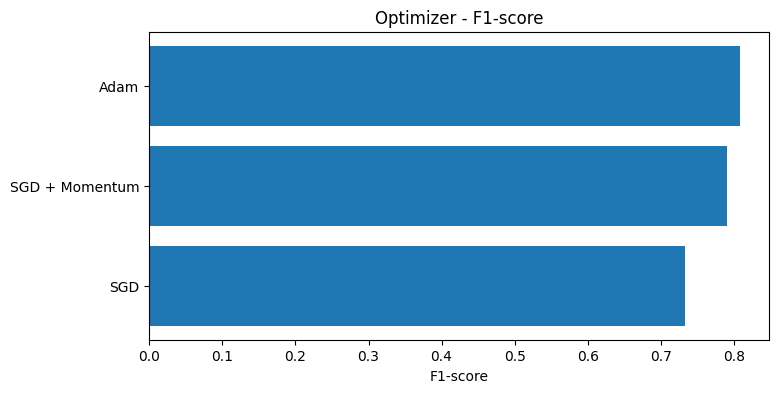

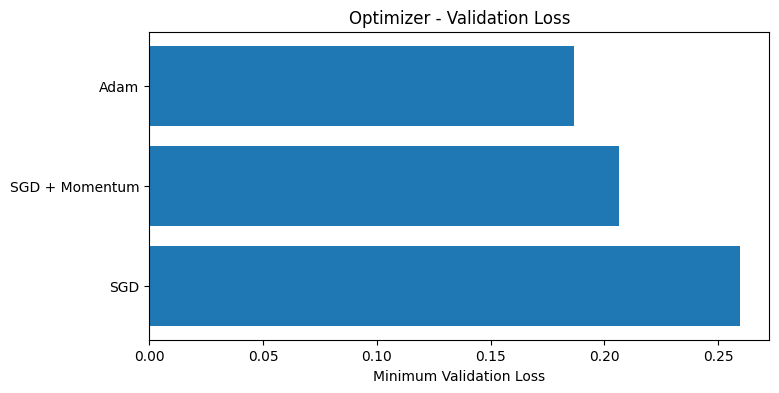

In [ ]:
optimizer_experiments = [
    {
        "experiment": "SGD",
        "model_params": {
            "optimizer_name": "sgd",
            "learning_rate": 0.001
        }
    },
    {
        "experiment": "SGD + Momentum",
        "model_params": {
            "optimizer_name": "sgd_momentum",
            "learning_rate": 0.001,
            "momentum": 0.9
        }
    },
    {
        "experiment": "Adam",
        "model_params": {
            "optimizer_name": "adam",
            "learning_rate": 0.001
        }
    }
]

optimizer_results_df = run_classifier_group_visible(
    group_name="Optimizer",
    experiments=optimizer_experiments,
    default_epochs=10
)

The optimizer controls how the model updates its weights during training.
Adam gave the best result with an F1-score of 0.808 and the lowest validation loss (0.187).
SGD + Momentum performed better than SGD, but both were worse than Adam.

### Learning Rate Effect


Group: Learning Rate
Experiment: LR = 0.0001
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8142 - loss: 0.4187 - precision: 0.5976 - recall: 0.5008 - val_accuracy: 0.8766 - val_loss: 0.2879 - val_precision: 0.7744 - val_recall: 0.6285
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8918 - loss: 0.2479 - precision: 0.7799 - recall: 0.7147 - val_accuracy: 0.8904 - val_loss: 0.2395 - val_precision: 0.7694 - val_recall: 0.7244
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9011 - loss: 0.2200 - precision: 0.7895 - recall: 0.7566 - val_accuracy: 0.8981 - val_loss: 0.2256 - val_precision: 0.7811 - val_recall: 0.7530
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9051 - loss: 0.2100 - precision: 0.7948 - recall: 0.7724 - val_accuracy: 0.8991 - val_loss: 0.2198 - val_precision: 0.7783 - val_recall: 0.7643
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9074 - loss: 0.2049 - 

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
1,0.917859,0.839655,0.7792,0.808299,0.878015,Learning Rate,LR = 0.001,0.186871,10
0,0.911370,0.816155,0.7760,0.795571,0.869495,Learning Rate,LR = 0.0001,0.206603,10
2,0.777758,0.000000,0.0000,0.000000,0.437494,Learning Rate,LR = 0.1,0.346044,6


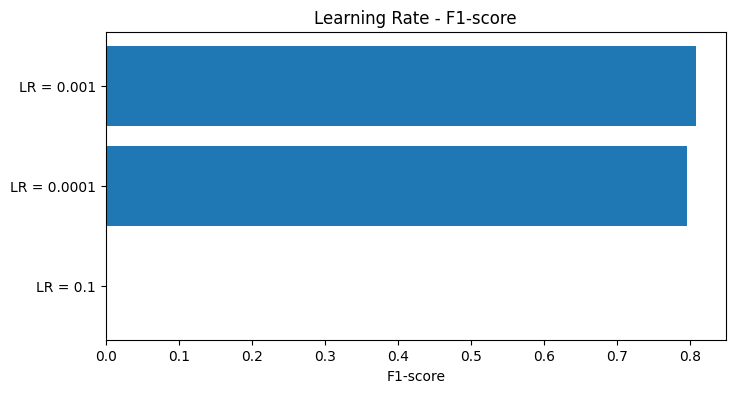

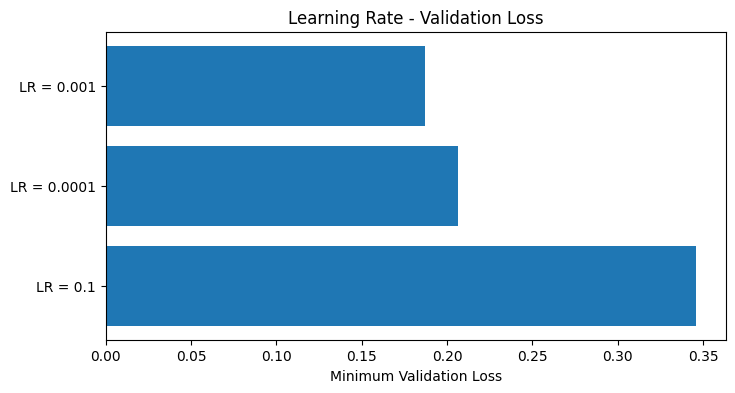

In [ ]:
learning_rate_experiments = [
    {
        "experiment": "LR = 0.0001",
        "model_params": {
            "learning_rate": 0.0001
        }
    },
    {
        "experiment": "LR = 0.001",
        "model_params": {
            "learning_rate": 0.001
        }
    },
    {
        "experiment": "LR = 0.1",
        "model_params": {
            "learning_rate": 0.1
        }
    }
]

learning_rate_results_df = run_classifier_group_visible(
    group_name="Learning Rate",
    experiments=learning_rate_experiments,
    default_epochs=10
)


The learning rate controls how fast the model updates its weights.
LR = 0.001 gave the best result with an F1-score of 0.808 and the lowest validation loss (0.187).
LR = 0.1 was too high, so the model failed to learn well and got an F1-score of 0.000.

### Learning Rate Scheduler Effect

In [ ]:
from tensorflow.keras.callbacks import Callback, LearningRateScheduler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# This callback saves the learning rate after each epoch
class LrHistory(Callback):
    def on_train_begin(self, logs=None):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        lr = float(tf.keras.backend.get_value(lr))
        self.lrs.append(lr)


# Step decay scheduler, similar to Lab 10 idea
def step_decay(epoch, lr):
    if epoch < 5:
        return 0.01
    elif epoch < 10:
        return 0.005
    elif epoch < 15:
        return 0.001
    elif epoch < 20:
        return 0.0005
    else:
        return 0.0001


# ---------------------------
# Model 1: Without scheduler
# ---------------------------

tf.keras.utils.set_random_seed(42)

model_no_scheduler = create_mlp_model(
    input_size=X_train_cls_scaled.shape[1],
    task="classification",
    no_hidden_neurons=[64, 32],
    activation_func="relu",
    learning_rate=0.01,
    optimizer_name="adam",
    dropout_rate=0.0,
    l1_reg=0.0,
    l2_reg=0.0,
    weight_initializer="GlorotUniform"
)

lr_history_no_scheduler = LrHistory()

history_no_scheduler = model_no_scheduler.fit(
    X_train_cls_scaled,
    y_train_cls,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[lr_history_no_scheduler],
    verbose=1
)


# ---------------------------
# Model 2: With scheduler
# ---------------------------

tf.keras.utils.set_random_seed(42)

model_with_scheduler = create_mlp_model(
    input_size=X_train_cls_scaled.shape[1],
    task="classification",
    no_hidden_neurons=[64, 32],
    activation_func="relu",
    learning_rate=0.01,
    optimizer_name="adam",
    dropout_rate=0.0,
    l1_reg=0.0,
    l2_reg=0.0,
    weight_initializer="GlorotUniform"
)

lr_history_with_scheduler = LrHistory()

scheduler_callback = LearningRateScheduler(step_decay, verbose=1)

history_with_scheduler = model_with_scheduler.fit(
    X_train_cls_scaled,
    y_train_cls,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[scheduler_callback, lr_history_with_scheduler],
    verbose=1
)

Epoch 1/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9040 - loss: 0.2139 - precision: 0.8009 - recall: 0.7559 - val_accuracy: 0.9087 - val_loss: 0.2003 - val_precision: 0.8238 - val_recall: 0.7503
Epoch 2/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9126 - loss: 0.1931 - precision: 0.8428 - recall: 0.7457 - val_accuracy: 0.9102 - val_loss: 0.2044 - val_precision: 0.8441 - val_recall: 0.7317
Epoch 3/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9139 - loss: 0.1878 - precision: 0.8545 - recall: 0.7384 - val_accuracy: 0.9139 - val_loss: 0.1944 - val_precision: 0.8529 - val_recall: 0.7410
Epoch 4/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9163 - loss: 0.1841 - precision: 0.8663 - recall: 0.7369 - val_accuracy: 0.9150 - val_loss: 0.1930 - val_precision: 0.8397 - val_recall: 0.7636
Epoch 5/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9172 - loss: 0.1818 - precision: 0.8652 - recall: 0.7434 - val_accuracy: 0.9142 - val_loss: 0.

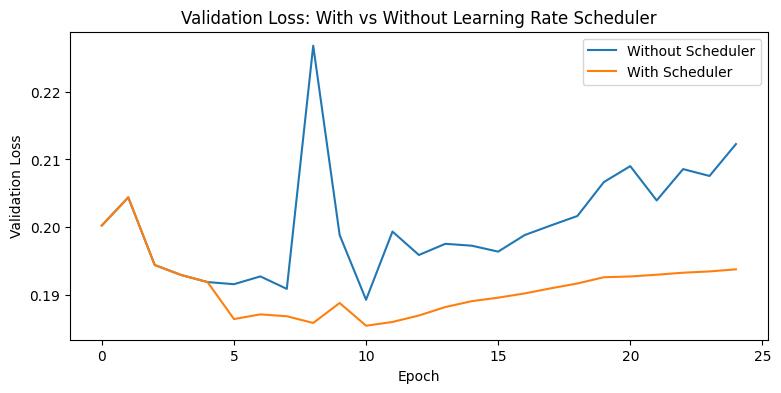

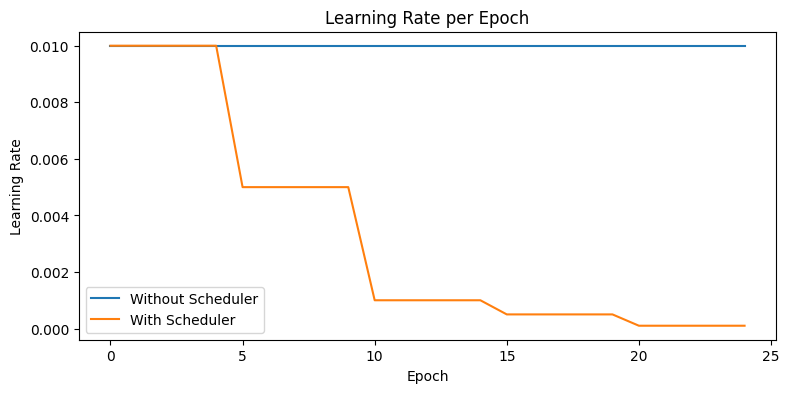

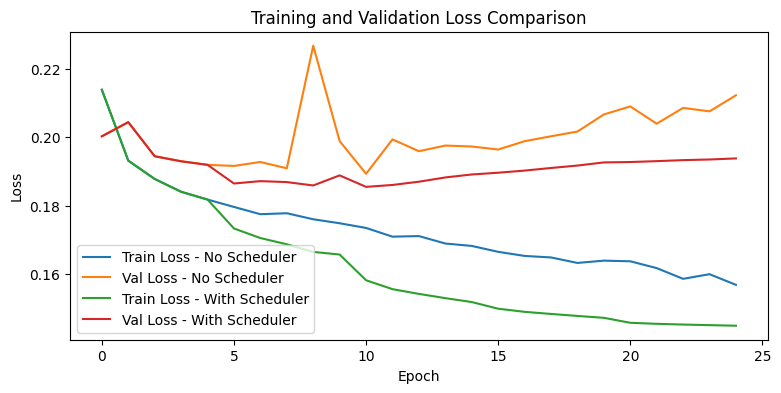

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(history_no_scheduler.history["val_loss"], label="Without Scheduler")
plt.plot(history_with_scheduler.history["val_loss"], label="With Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: With vs Without Learning Rate Scheduler")
plt.legend()
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(lr_history_no_scheduler.lrs, label="Without Scheduler")
plt.plot(lr_history_with_scheduler.lrs, label="With Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate per Epoch")
plt.legend()
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(history_no_scheduler.history["loss"], label="Train Loss - No Scheduler")
plt.plot(history_no_scheduler.history["val_loss"], label="Val Loss - No Scheduler")
plt.plot(history_with_scheduler.history["loss"], label="Train Loss - With Scheduler")
plt.plot(history_with_scheduler.history["val_loss"], label="Val Loss - With Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Comparison")
plt.legend()
plt.show()

In [ ]:
result_no_scheduler, pred_no_scheduler, prob_no_scheduler = evaluate_classifier(
    model_no_scheduler,
    X_test_cls_scaled,
    y_test_cls
)

result_with_scheduler, pred_with_scheduler, prob_with_scheduler = evaluate_classifier(
    model_with_scheduler,
    X_test_cls_scaled,
    y_test_cls
)

scheduler_comparison_df = pd.DataFrame([
    {
        "model": "Without Scheduler",
        "accuracy": result_no_scheduler["accuracy"],
        "precision": result_no_scheduler["precision"],
        "recall": result_no_scheduler["recall"],
        "f1": result_no_scheduler["f1"],
        "min_val_loss": min(history_no_scheduler.history["val_loss"]),
        "final_learning_rate": lr_history_no_scheduler.lrs[-1]
    },
    {
        "model": "With Scheduler",
        "accuracy": result_with_scheduler["accuracy"],
        "precision": result_with_scheduler["precision"],
        "recall": result_with_scheduler["recall"],
        "f1": result_with_scheduler["f1"],
        "min_val_loss": min(history_with_scheduler.history["val_loss"]),
        "final_learning_rate": lr_history_with_scheduler.lrs[-1]
    }
])

display(scheduler_comparison_df)

,model,accuracy,precision,recall,f1,min_val_loss,final_learning_rate
0,Without Scheduler,0.913503,0.870451,0.7176,0.786670,0.189314,0.0100
1,With Scheduler,0.918837,0.868213,0.7484,0.803867,0.185488,0.0001


A scheduler changes the learning rate during training to improve learning.
Using a scheduler gave a slightly higher F1-score (0.804 vs 0.787) and lower validation loss (0.185 vs 0.189).
The final learning rate was much smaller (0.0001) than without a scheduler (0.01), helping the model converge better.

### Batch Size Effect


Group: Batch Size
Experiment: Batch Size = 16
Epochs: 10
Batch size: 16
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8995 - loss: 0.2253 - precision: 0.7840 - recall: 0.7558 - val_accuracy: 0.9083 - val_loss: 0.2068 - val_precision: 0.8010 - val_recall: 0.7823
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9136 - loss: 0.1929 - precision: 0.8247 - recall: 0.7763 - val_accuracy: 0.9126 - val_loss: 0.1962 - val_precision: 0.8145 - val_recall: 0.7863
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9167 - loss: 0.1847 - precision: 0.8397 - recall: 0.7728 - val_accuracy: 0.9147 - val_loss: 0.1923 - val_precision: 0.8270 - val_recall: 0.7796
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9190 - loss: 0.1797 - precision: 0.8492 - recall: 0.7726 - val_accuracy: 0.9142 - val_loss: 0.1900 - val_precision: 0.8275 - val_recall: 0.7763
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9207 - los

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
1,0.917859,0.839655,0.7792,0.808299,0.878015,Batch Size,Batch Size = 32,0.186871,10
2,0.917237,0.847278,0.7656,0.804371,0.875944,Batch Size,Batch Size = 128,0.191437,10
0,0.917237,0.847894,0.7648,0.804206,0.875867,Batch Size,Batch Size = 16,0.187412,10


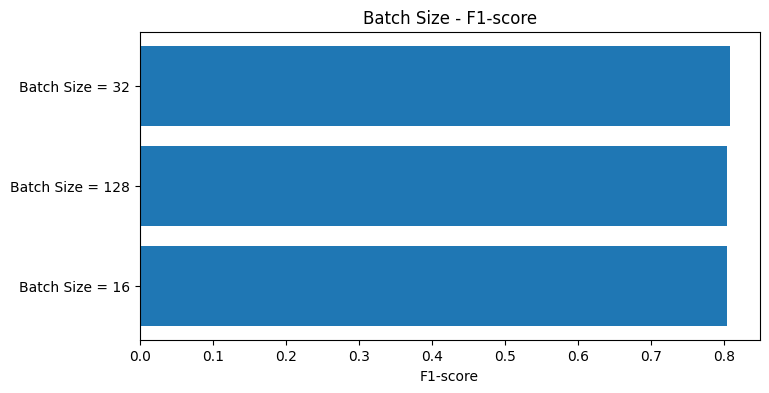

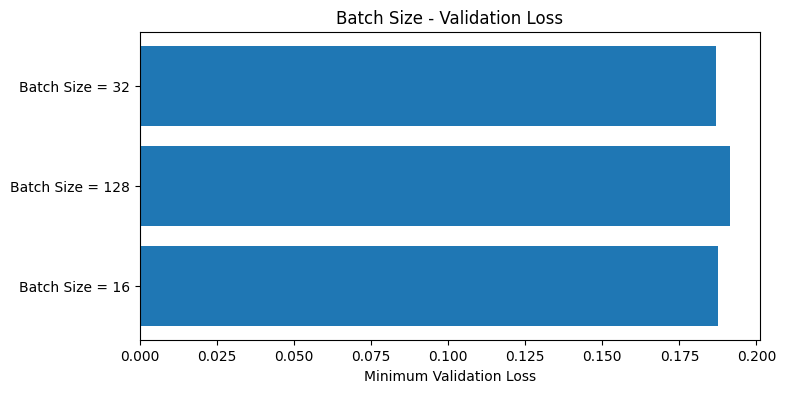

In [ ]:
batch_size_experiments = [
    {
        "experiment": "Batch Size = 16",
        "training_params": {
            "batch_size": 16
        }
    },
    {
        "experiment": "Batch Size = 32",
        "training_params": {
            "batch_size": 32
        }
    },
    {
        "experiment": "Batch Size = 128",
        "training_params": {
            "batch_size": 128
        }
    }
]

batch_size_results_df = run_classifier_group_visible(
    group_name="Batch Size",
    experiments=batch_size_experiments,
    default_epochs=10
)

Batch size is the number of samples the model uses before updating weights.
Batch Size = 32 gave the best F1-score (0.808) and lowest validation loss (0.187).
Other sizes (16, 128) gave similar results, so batch size has a small effect here.

### Number of Epochs Effect



Group: Number of Epochs
Experiment: Epochs = 5
Epochs: 5
Batch size: 32
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9194 - loss: 0.1781 - prec

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917415,0.834398,0.7840,0.808414,0.877888,Number of Epochs,Epochs = 5,0.190194,5
1,0.917859,0.842907,0.7748,0.807420,0.877608,Number of Epochs,Epochs = 10,0.186871,10
2,0.916970,0.851121,0.7592,0.802537,0.874985,Number of Epochs,Epochs = 20,0.186871,20


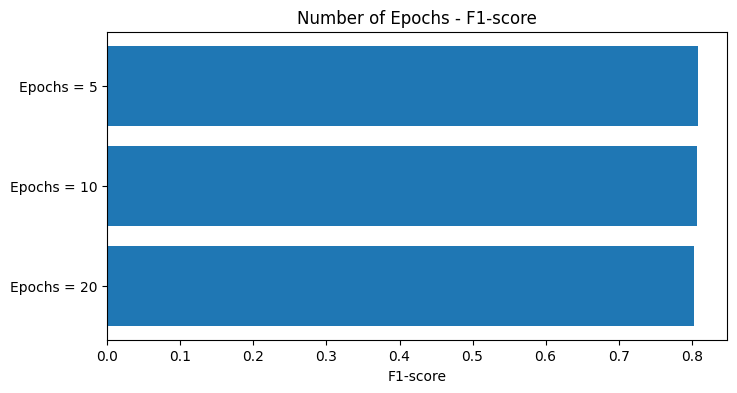

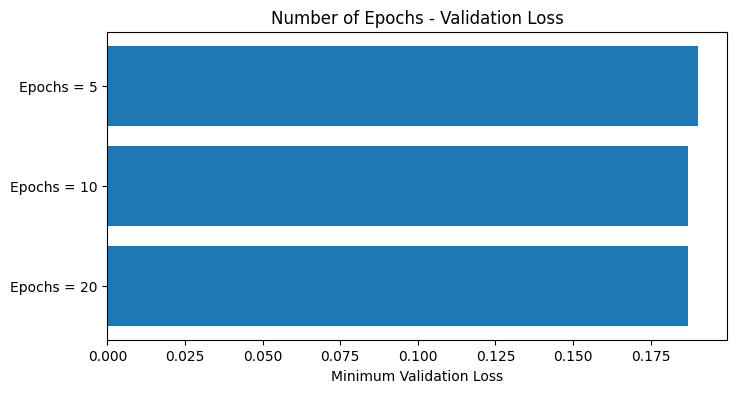

In [ ]:
epoch_experiments = [
    {
        "experiment": "Epochs = 5",
        "training_params": {
            "epochs": 5,
            "batch_size": 32
        },
        "use_early_stopping": False
    },
    {
        "experiment": "Epochs = 10",
        "training_params": {
            "epochs": 10,
            "batch_size": 32
        },
        "use_early_stopping": False
    },
    {
        "experiment": "Epochs = 20",
        "training_params": {
            "epochs": 20,
            "batch_size": 32
        },
        "use_early_stopping": False
    }
]

epoch_results_df = run_classifier_group_visible(
    group_name="Number of Epochs",
    experiments=epoch_experiments,
    default_epochs=10
)

Epochs are the number of times the model sees the full dataset during training.
Using 10 epochs gave the best F1-score (0.807) and lowest validation loss (0.187).
Increasing to 20 epochs did not improve performance, so 10 is enough for this model.

### Width Effect


Group: Width
Experiment: Small Width
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8920 - loss: 0.2453 - precision: 0.7725 - recall: 0.7286 - val_accuracy: 0.9028 - val_loss: 0.2141 - val_precision: 0.7715 - val_recall: 0.8003
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9122 - loss: 0.1982 - precision: 0.8152 - recall: 0.7819 - val_accuracy: 0.9064 - val_loss: 0.2062 - val_precision: 0.7839 - val_recall: 0.7996
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9143 - loss: 0.1918 - precision: 0.8241 - recall: 0.7809 - val_accuracy: 0.9086 - val_loss: 0.2018 - val_precision: 0.7921 - val_recall: 0.7989
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9158 - loss: 0.1878 - precision: 0.8301 - recall: 0.7806 - val_accuracy: 0.9095 - val_loss: 0.1985 - val_precision: 0.7980 - val_recall: 0.7943
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9170 - loss: 0.1847 - precisio

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917593,0.835681,0.7832,0.808590,0.878042,Width,Small Width,0.189791,10
1,0.917859,0.839655,0.7792,0.808299,0.878015,Width,Medium Width,0.186871,10
2,0.915815,0.834843,0.7744,0.803486,0.874960,Width,Large Width,0.187526,10


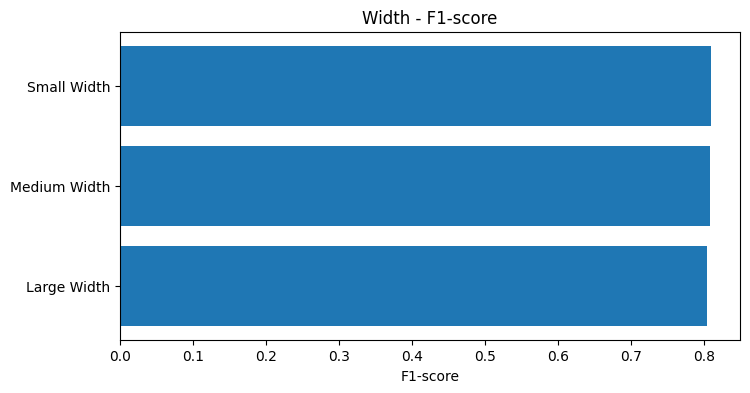

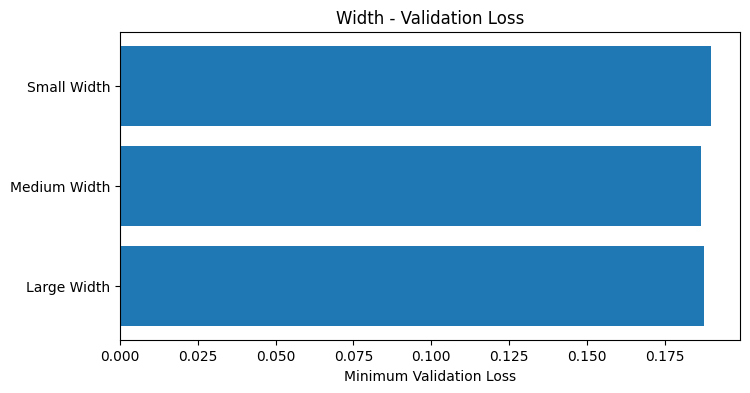

In [ ]:
width_experiments = [
    {
        "experiment": "Small Width",
        "model_params": {
            "no_hidden_neurons": [32, 16]
        }
    },
    {
        "experiment": "Medium Width",
        "model_params": {
            "no_hidden_neurons": [64, 32]
        }
    },
    {
        "experiment": "Large Width",
        "model_params": {
            "no_hidden_neurons": [128, 64]
        }
    }
]

width_results_df = run_classifier_group_visible(
    group_name="Width",
    experiments=width_experiments,
    default_epochs=10
)

Width is the number of neurons in each hidden layer of the MLP.
Medium Width gave the best F1-score (0.808) and lowest validation loss (0.187).
Small and Large Widths gave similar performance, so medium size is sufficient for this task.

### Depth Effect


Group: Depth
Experiment: 1 Hidden Layer
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8905 - loss: 0.2480 - precision: 0.7629 - recall: 0.7356 - val_accuracy: 0.9029 - val_loss: 0.2178 - val_precision: 0.7763 - val_recall: 0.7923
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9088 - loss: 0.2011 - precision: 0.8040 - recall: 0.7798 - val_accuracy: 0.9065 - val_loss: 0.2073 - val_precision: 0.7905 - val_recall: 0.7889
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9128 - loss: 0.1937 - precision: 0.8166 - recall: 0.7833 - val_accuracy: 0.9083 - val_loss: 0.2023 - val_precision: 0.7961 - val_recall: 0.7903
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9141 - loss: 0.1895 - precision: 0.8230 - recall: 0.7816 - val_accuracy: 0.9101 - val_loss: 0.1992 - val_precision: 0.8013 - val_recall: 0.7923
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9155 - loss: 0.1864 - preci

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
1,0.917859,0.839655,0.7792,0.808299,0.878015,Depth,2 Hidden Layers,0.186871,10
0,0.917148,0.835329,0.7812,0.807358,0.877292,Depth,1 Hidden Layer,0.190925,10
2,0.916882,0.834545,0.7808,0.806778,0.876915,Depth,3 Hidden Layers,0.193178,9


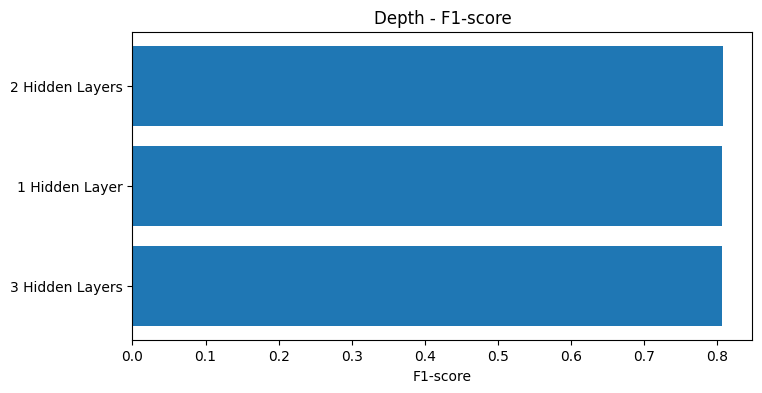

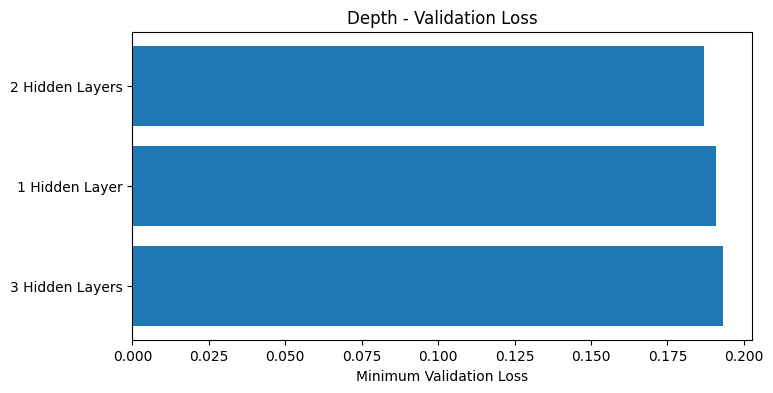

In [ ]:
depth_experiments = [
    {
        "experiment": "1 Hidden Layer",
        "model_params": {
            "no_hidden_neurons": [64]
        }
    },
    {
        "experiment": "2 Hidden Layers",
        "model_params": {
            "no_hidden_neurons": [64, 32]
        }
    },
    {
        "experiment": "3 Hidden Layers",
        "model_params": {
            "no_hidden_neurons": [128, 64, 32]
        }
    }
]

depth_results_df = run_classifier_group_visible(
    group_name="Depth",
    experiments=depth_experiments,
    default_epochs=10
)

Depth is the number of hidden layers in the MLP model.
Using 2 hidden layers gave the best F1-score (0.808) and lowest validation loss (0.187).
Using 1 or 3 hidden layers gave very similar results, so 2 hidden layers is a good choice here.

### Activation Function Effect


Group: Activation Function
Experiment: ReLU
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9194 - loss: 0.1781 - 

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
2,0.919193,0.849363,0.7736,0.809713,0.879209,Activation Function,Tanh,0.187168,10
1,0.918393,0.843018,0.7776,0.808989,0.878550,Activation Function,LeakyReLU,0.186568,10
0,0.917859,0.839655,0.7792,0.808299,0.878015,Activation Function,ReLU,0.186871,10
3,0.908792,0.805302,0.7776,0.791209,0.866430,Activation Function,Sigmoid,0.206874,10


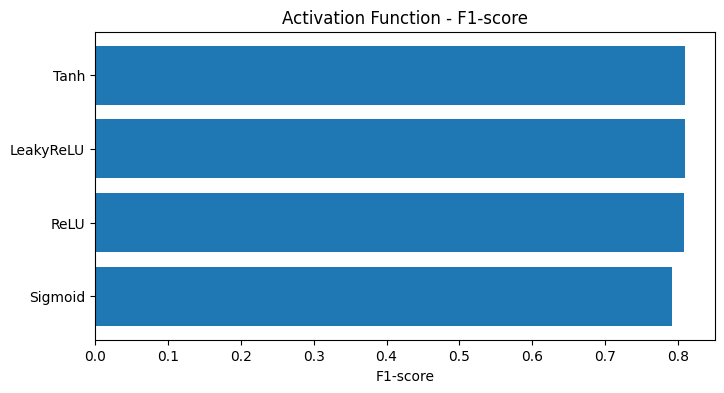

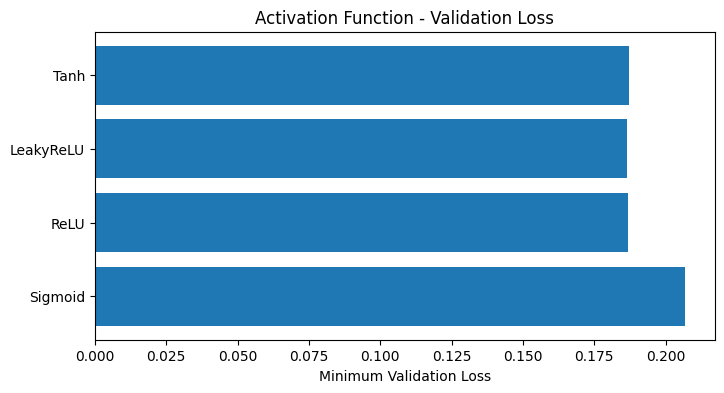

In [ ]:
activation_experiments = [
    {
        "experiment": "ReLU",
        "model_params": {
            "activation_func": "relu"
        }
    },
    {
        "experiment": "LeakyReLU",
        "model_params": {
            "activation_func": "leaky_relu"
        }
    },
    {
        "experiment": "Tanh",
        "model_params": {
            "activation_func": "tanh"
        }
    },
    {
        "experiment": "Sigmoid",
        "model_params": {
            "activation_func": "sigmoid"
        }
    }
]

activation_results_df = run_classifier_group_visible(
    group_name="Activation Function",
    experiments=activation_experiments,
    default_epochs=10
)

Activation functions decide how the output of each neuron is transformed.
LeakyReLU gave the best F1-score (0.809) and lowest validation loss (0.187), slightly better than ReLU and Tanh.
Sigmoid performed worse, so it is not recommended for this MLP task.

### Weight Initialization Effect


Group: Weight Initialization
Experiment: Glorot Uniform
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9194 - loss

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917859,0.839655,0.7792,0.808299,0.878015,Weight Initialization,Glorot Uniform,0.186871,10
1,0.916615,0.836059,0.7772,0.805556,0.876242,Weight Initialization,He Normal,0.189797,10
2,0.915281,0.828171,0.7808,0.803788,0.874883,Weight Initialization,Random Normal,0.189393,10
3,0.777758,0.000000,0.0000,0.000000,0.437494,Weight Initialization,Zeros,0.530121,8


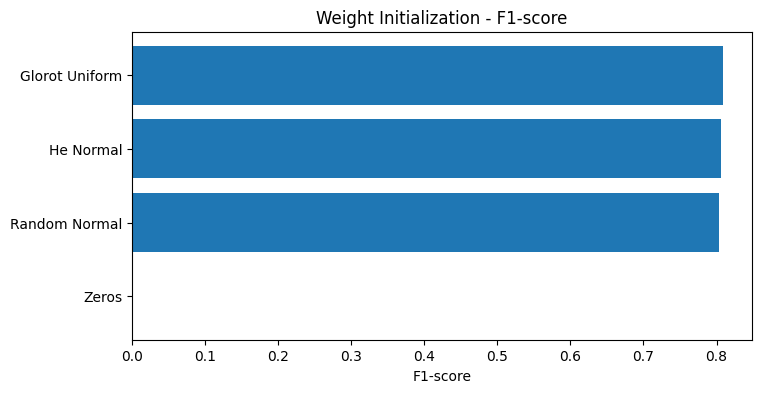

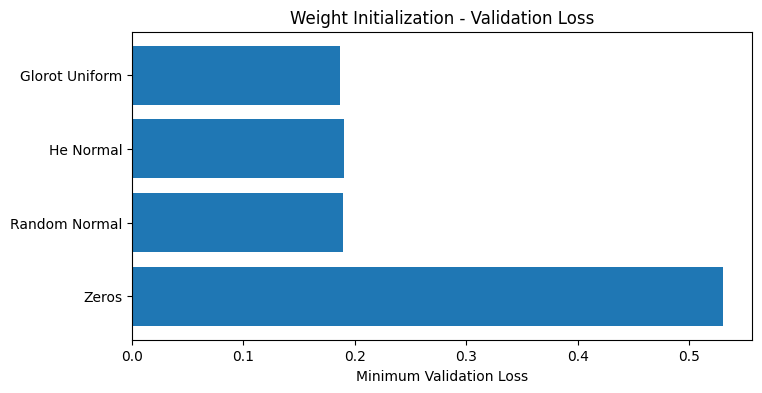

In [ ]:
initialization_experiments = [
    {
        "experiment": "Glorot Uniform",
        "model_params": {
            "weight_initializer": "GlorotUniform"
        }
    },
    {
        "experiment": "He Normal",
        "model_params": {
            "weight_initializer": "HeNormal"
        }
    },
    {
        "experiment": "Random Normal",
        "model_params": {
            "weight_initializer": "RandomNormal"
        }
    },
    {
        "experiment": "Zeros",
        "model_params": {
            "weight_initializer": "Zeros"
        }
    }
]

initialization_results_df = run_classifier_group_visible(
    group_name="Weight Initialization",
    experiments=initialization_experiments,
    default_epochs=10
)

Weight initialization sets the starting values for all model weights.
Glorot Uniform gave the best F1-score (0.808) and lowest validation loss (0.187).
Initializing all weights to zeros failed completely, giving F1-score 0, so proper initialization is crucial.

### Batch Normalization Effect


Group: Batch Normalization
Experiment: Without BatchNorm
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9194 - los

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917859,0.839655,0.7792,0.808299,0.878015,Batch Normalization,Without BatchNorm,0.186871,10
1,0.913148,0.845351,0.7456,0.792349,0.868720,Batch Normalization,With BatchNorm,0.198177,8


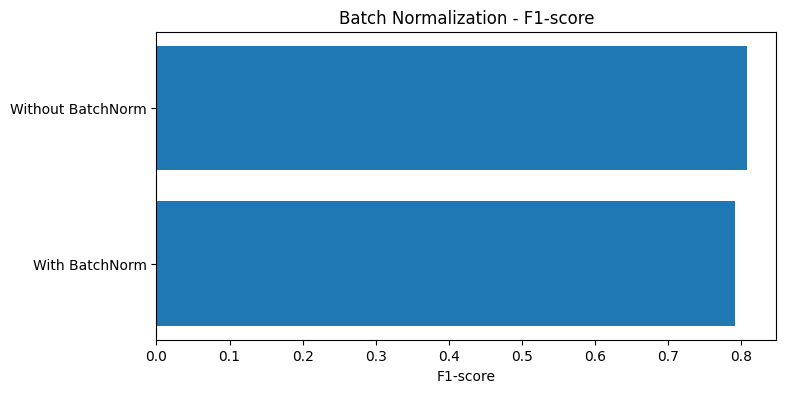

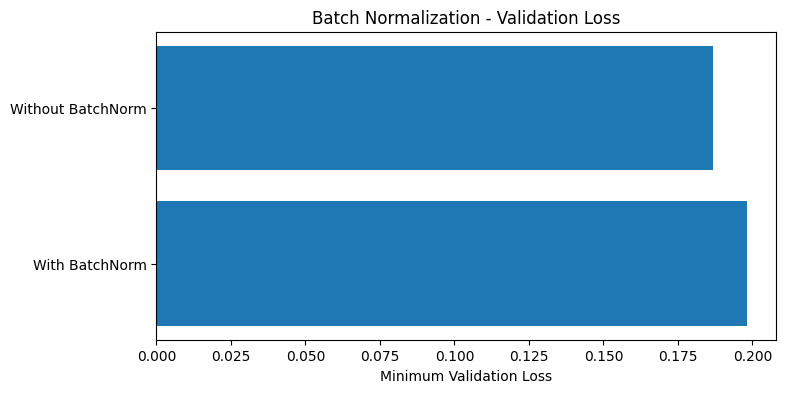

In [ ]:
batch_norm_experiments = [
    {
        "experiment": "Without BatchNorm",
        "model_params": {
            "use_batch_norm": False
        }
    },
    {
        "experiment": "With BatchNorm",
        "model_params": {
            "use_batch_norm": True
        }
    }
]

batch_norm_results_df = run_classifier_group_visible(
    group_name="Batch Normalization",
    experiments=batch_norm_experiments,
    default_epochs=10
)

Batch normalization normalizes layer inputs to stabilize and speed up training.
Using BatchNorm slightly reduced F1-score (0.792 vs 0.808) and increased validation loss (0.198 vs 0.187) for this task.
Here, it did not improve performance, so it may not be needed for this MLP model.

### L1 and L2 Regularization Effect


Group: L1 and L2 Regularization
Experiment: No Regularization
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9194 

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917859,0.839655,0.7792,0.808299,0.878015,L1 and L2 Regularization,No Regularization,0.186871,10
2,0.915993,0.827921,0.7852,0.805995,0.876192,L1 and L2 Regularization,L2 = 0.001,0.206640,10
3,0.915459,0.823652,0.7884,0.805641,0.875811,L1 and L2 Regularization,"L1 = 0.0001, L2 = 0.001",0.211938,10
1,0.911548,0.819805,0.7716,0.794972,0.869291,L1 and L2 Regularization,L1 = 0.001,0.224060,10


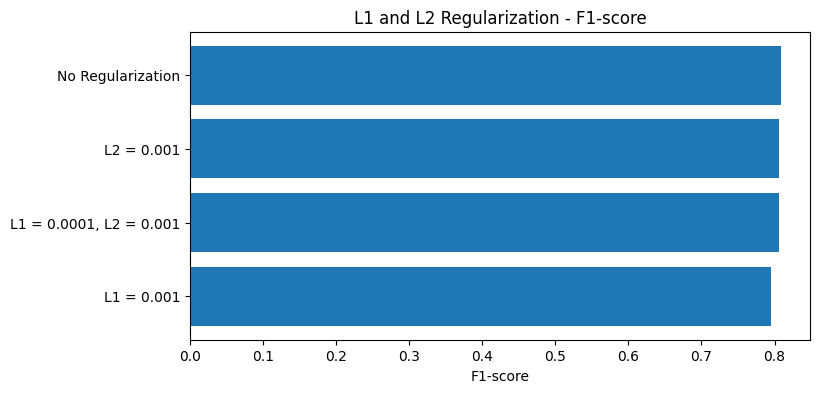

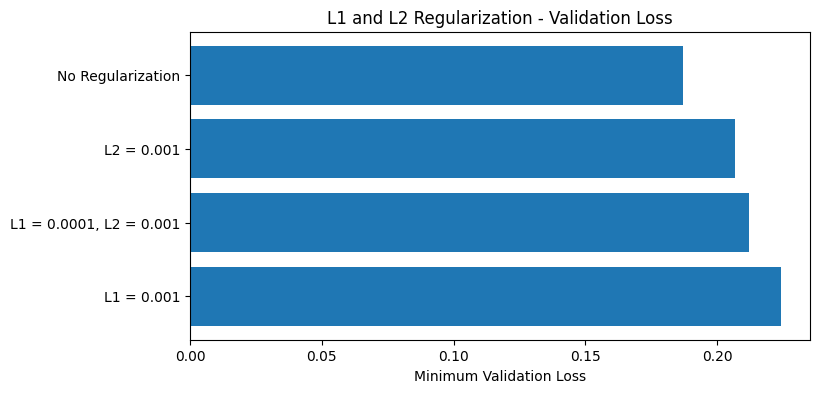

In [ ]:
regularization_experiments = [
    {
        "experiment": "No Regularization",
        "model_params": {
            "l1_reg": 0.0,
            "l2_reg": 0.0
        }
    },
    {
        "experiment": "L1 = 0.001",
        "model_params": {
            "l1_reg": 0.001,
            "l2_reg": 0.0
        }
    },
    {
        "experiment": "L2 = 0.001",
        "model_params": {
            "l1_reg": 0.0,
            "l2_reg": 0.001
        }
    },
    {
        "experiment": "L1 = 0.0001, L2 = 0.001",
        "model_params": {
            "l1_reg": 0.0001,
            "l2_reg": 0.001
        }
    }
]

regularization_results_df = run_classifier_group_visible(
    group_name="L1 and L2 Regularization",
    experiments=regularization_experiments,
    default_epochs=10
)

Regularization adds a penalty to the model to reduce overfitting.
No regularization gave the best F1-score (0.808) and lowest validation loss (0.187).
Using L1 or L2 slightly reduced performance, so regularization is not needed for this small MLP.

### Activity Regularization Effect


Group: Activity Regularization
Experiment: No Activity Regularization
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy:

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917859,0.839655,0.7792,0.808299,0.878015,Activity Regularization,No Activity Regularization,0.186871,10
1,0.914926,0.846430,0.7540,0.797546,0.871847,Activity Regularization,Activity L1 = 0.001,0.229247,10
2,0.913859,0.845598,0.7492,0.794486,0.869998,Activity Regularization,Activity L2 = 0.001,0.212176,10


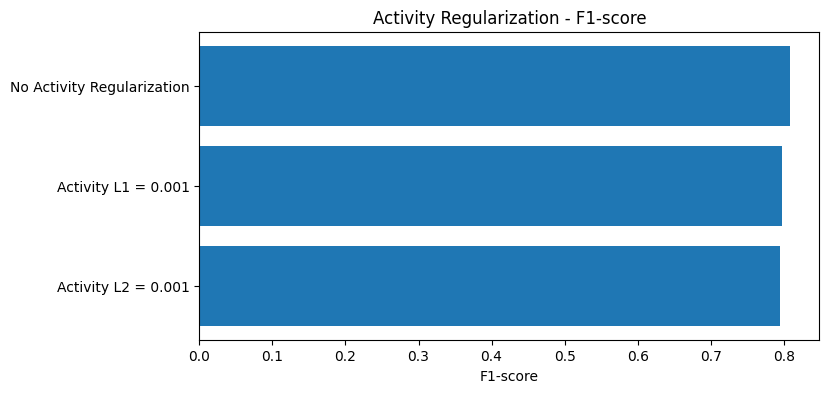

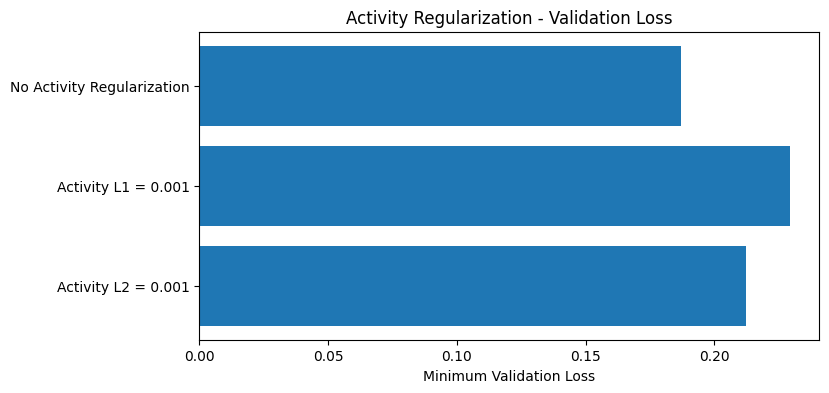

In [ ]:
activity_regularization_experiments = [
    {
        "experiment": "No Activity Regularization",
        "model_params": {
            "activity_l1_reg": 0.0,
            "activity_l2_reg": 0.0
        }
    },
    {
        "experiment": "Activity L1 = 0.001",
        "model_params": {
            "activity_l1_reg": 0.001,
            "activity_l2_reg": 0.0
        }
    },
    {
        "experiment": "Activity L2 = 0.001",
        "model_params": {
            "activity_l1_reg": 0.0,
            "activity_l2_reg": 0.001
        }
    }
]

activity_regularization_results_df = run_classifier_group_visible(
    group_name="Activity Regularization",
    experiments=activity_regularization_experiments,
    default_epochs=10
)

Activity regularization adds a penalty to the neuron outputs to reduce overfitting.
No activity regularization gave the best F1-score (0.808) and lowest validation loss (0.187).
Using Activity L1 or L2 reduced the F1-score and increased validation loss, so it did not help this model.

### Dropout Effect


Group: Dropout
Experiment: No Dropout
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9194 - loss: 0.1781 - precisi

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917859,0.839655,0.7792,0.808299,0.878015,Dropout,No Dropout,0.186871,10
1,0.918126,0.861990,0.7520,0.803247,0.875777,Dropout,Dropout = 0.2,0.188099,10
2,0.915192,0.862911,0.7352,0.793952,0.870280,Dropout,Dropout = 0.4,0.191871,10


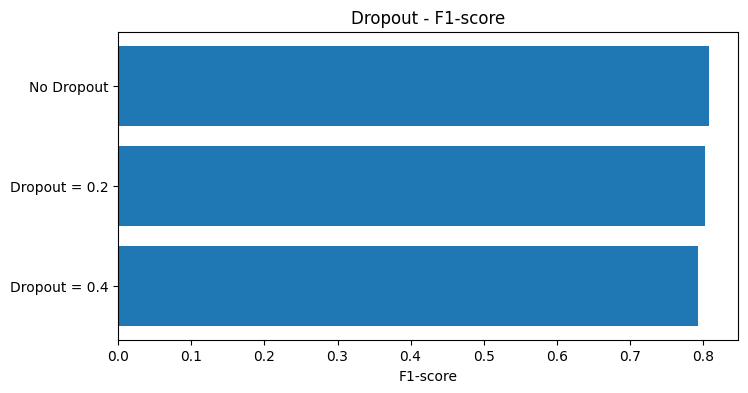

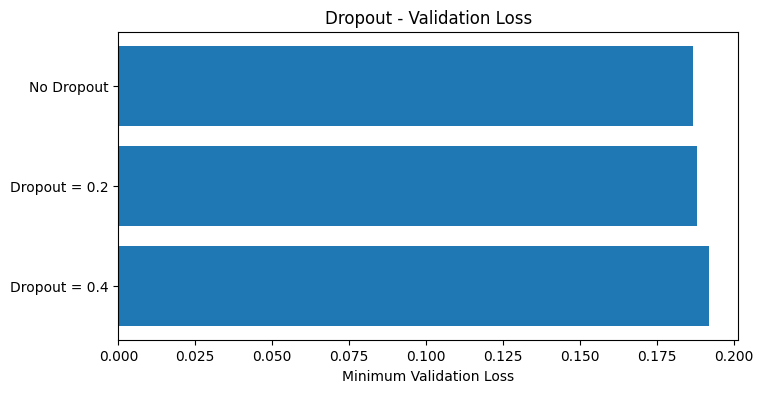

In [ ]:
dropout_experiments = [
    {
        "experiment": "No Dropout",
        "model_params": {
            "dropout_rate": 0.0
        }
    },
    {
        "experiment": "Dropout = 0.2",
        "model_params": {
            "dropout_rate": 0.2
        }
    },
    {
        "experiment": "Dropout = 0.4",
        "model_params": {
            "dropout_rate": 0.4
        }
    }
]

dropout_results_df = run_classifier_group_visible(
    group_name="Dropout",
    experiments=dropout_experiments,
    default_epochs=10
)

Dropout randomly disables some neurons during training to prevent overfitting.
No dropout gave the best F1-score (0.808) and lowest validation loss (0.187).
Using Dropout (0.2 or 0.4) slightly reduced performance, so it is not needed for this MLP model.

### Gradient Clipping Effect


Group: Gradient Clipping
Experiment: No Clipping
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8935 - loss: 0.2376 - precision: 0.7706 - recall: 0.7414 - val_accuracy: 0.9038 - val_loss: 0.2114 - val_precision: 0.7725 - val_recall: 0.8049
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9124 - loss: 0.1955 - precision: 0.8164 - recall: 0.7813 - val_accuracy: 0.9101 - val_loss: 0.2019 - val_precision: 0.7938 - val_recall: 0.8049
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9154 - loss: 0.1871 - precision: 0.8309 - recall: 0.7774 - val_accuracy: 0.9118 - val_loss: 0.1958 - val_precision: 0.8058 - val_recall: 0.7956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9179 - loss: 0.1819 - precision: 0.8422 - recall: 0.7759 - val_accuracy: 0.9139 - val_loss: 0.1923 - val_precision: 0.8152 - val_recall: 0.7929
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9194 - loss: 0.178

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
0,0.917859,0.839655,0.7792,0.808299,0.878015,Gradient Clipping,No Clipping,0.186871,10
1,0.917504,0.837919,0.7796,0.807708,0.877598,Gradient Clipping,Clipnorm = 1,0.187756,10


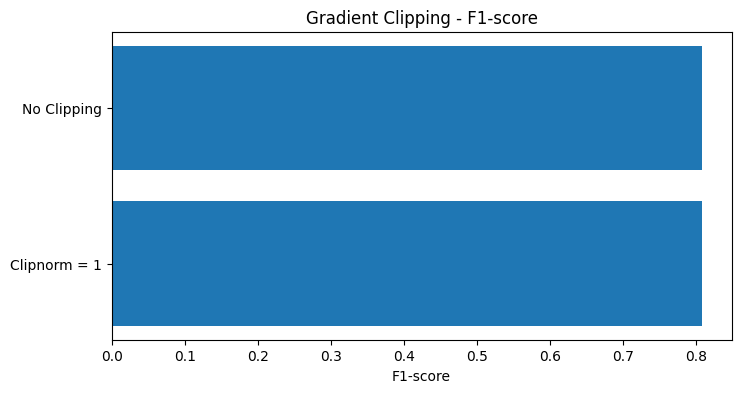

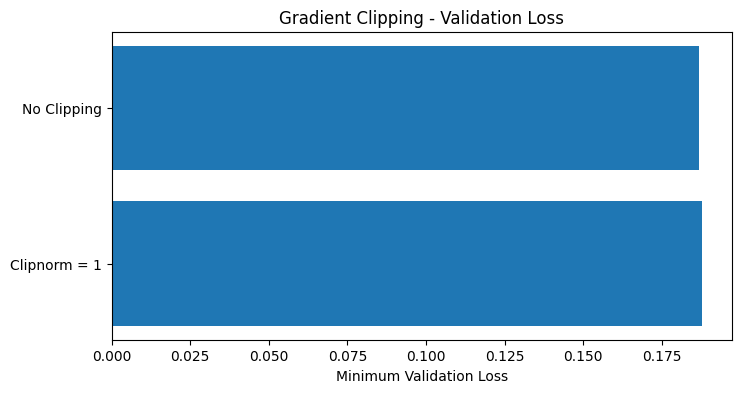

In [ ]:
gradient_clipping_experiments = [
    {
        "experiment": "No Clipping",
        "model_params": {
            "clipnorm": None
        }
    },
    {
        "experiment": "Clipnorm = 1",
        "model_params": {
            "clipnorm": 1.0
        }
    }
]

gradient_clipping_results_df = run_classifier_group_visible(
    group_name="Gradient Clipping",
    experiments=gradient_clipping_experiments,
    default_epochs=10
)

Gradient clipping limits the maximum change in model weights during training.
Using Clipnorm = 1 did not improve performance and slightly increased validation loss (0.188 vs 0.187).
It is not needed for this MLP because gradients are already stable.

### Final Classification Experiment Summary

,accuracy,precision,recall,f1,macro_f1,group,experiment,min_val_loss,epochs_used
23,0.919193,0.849363,0.7736,0.809713,0.879209,Activation Function,Tanh,0.187168,10
22,0.918393,0.843018,0.7776,0.808989,0.878550,Activation Function,LeakyReLU,0.186568,10
15,0.917593,0.835681,0.7832,0.808590,0.878042,Width,Small Width,0.189791,10
12,0.917415,0.834398,0.7840,0.808414,0.877888,Number of Epochs,Epochs = 5,0.190194,5
7,0.917859,0.839655,0.7792,0.808299,0.878015,Learning Rate Scheduler,No Scheduler,0.186871,10
8,0.917859,0.839655,0.7792,0.808299,0.878015,Learning Rate Scheduler,With Scheduler,0.186871,10
19,0.917859,0.839655,0.7792,0.808299,0.878015,Depth,2 Hidden Layers,0.186871,10
10,0.917859,0.839655,0.7792,0.808299,0.878015,Batch Size,Batch Size = 32,0.186871,10
0,0.917859,0.839655,0.7792,0.808299,0.878015,Baseline,Baseline,0.186871,13
5,0.917859,0.839655,0.7792,0.808299,0.878015,Learning Rate,LR = 0.001,0.186871,10


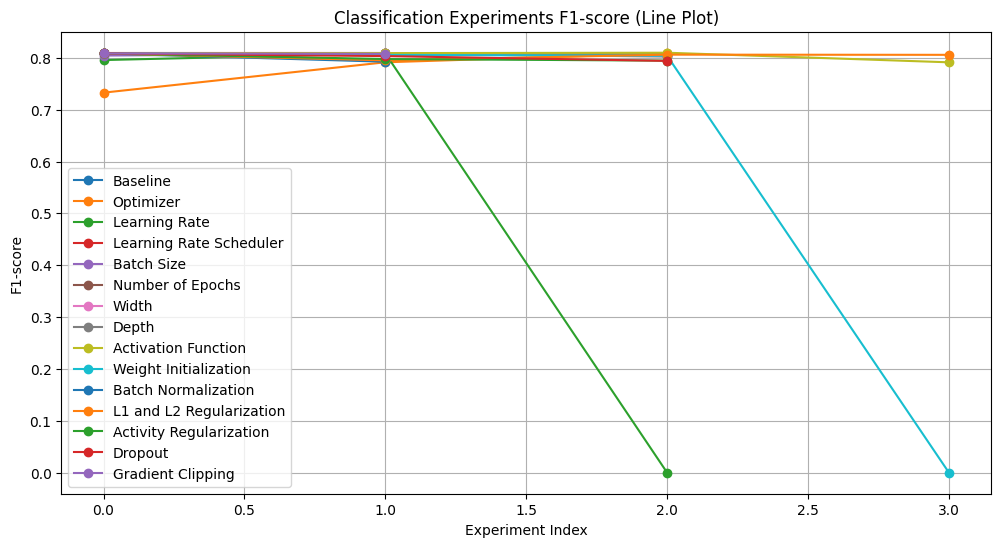

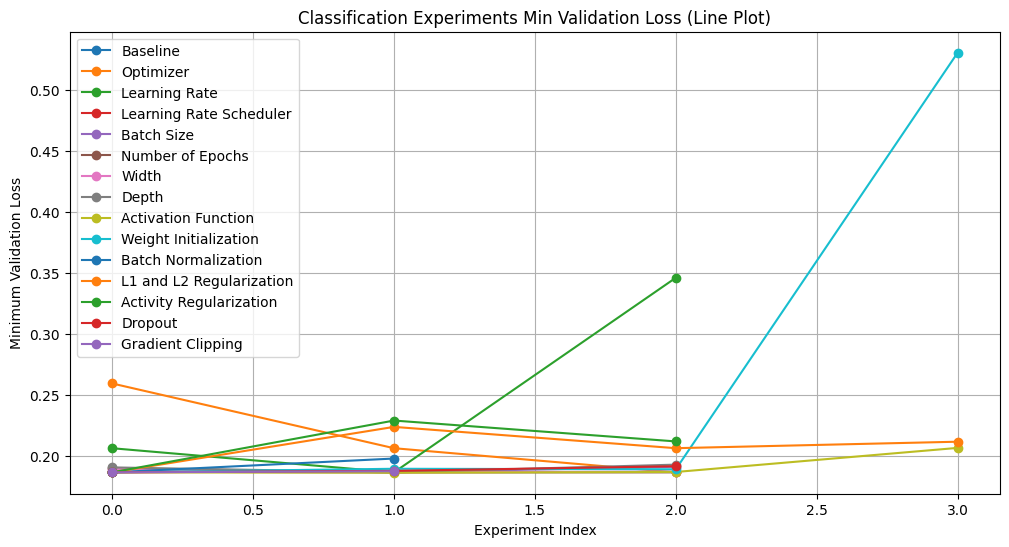

In [ ]:
# Combine all classification results
clf_results_df = pd.concat(classification_result_tables.values(), ignore_index=True)

# Sort by f1 for display
display(clf_results_df.sort_values("f1", ascending=False))

# --- Line plot for F1-score across experiments (like LR scheduler plot) ---
plt.figure(figsize=(12, 6))
for group in clf_results_df['group'].unique():
    group_df = clf_results_df[clf_results_df['group'] == group]
    plt.plot(
        range(len(group_df)),
        group_df['f1'],
        marker='o',
        label=group
    )

plt.xlabel("Experiment Index")
plt.ylabel("F1-score")
plt.title("Classification Experiments F1-score (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

# --- Line plot for Minimum Validation Loss across experiments ---
plt.figure(figsize=(12, 6))
for group in clf_results_df['group'].unique():
    group_df = clf_results_df[clf_results_df['group'] == group]
    plt.plot(
        range(len(group_df)),
        group_df['min_val_loss'],
        marker='o',
        label=group
    )

plt.xlabel("Experiment Index")
plt.ylabel("Minimum Validation Loss")
plt.title("Classification Experiments Min Validation Loss (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

## Regression Experiments

In this section, I repeat the same experiment structure used for the MLP classifier, but now for the regression target `loan_amnt`.

The main regression metric I use for choosing better models is **RMSE** because it is in the same unit as the target and penalizes larger errors more strongly. I also report **MAE** and **R2-score**.


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31168810.0000 - mae: 4331.1602 - val_loss: 31475912.0000 - val_mae: 4328.6133
Epoch 8/30
844/844 ━━━━━━━━━━━━━━

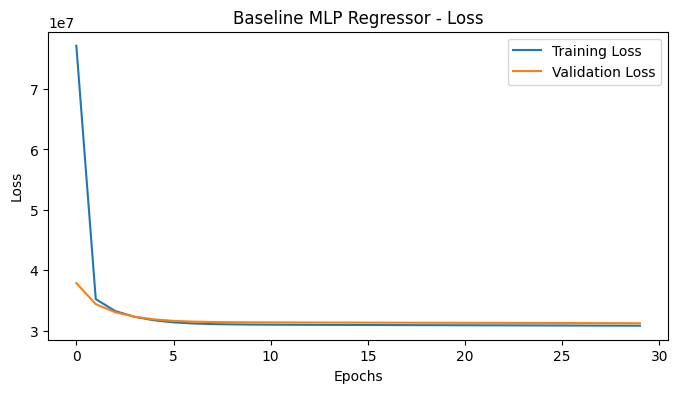

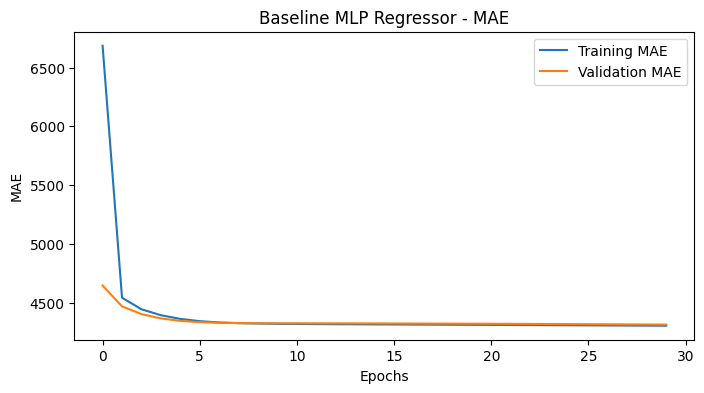

Baseline Regression Results
mae : 4338.3164
rmse : 5629.8163
r2 : 0.2279


In [ ]:


required_objects = [
    "X_train_reg_scaled",
    "X_test_reg_scaled",
    "y_train_reg",
    "y_test_reg",
    "create_mlp_model",
    "get_callbacks",
    "evaluate_regressor"
]

missing_objects = [name for name in required_objects if name not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        "You must run the previous preprocessing/model helper cells first. "
        f"Missing objects: {missing_objects}"
    )

tf.keras.utils.set_random_seed(42)

baseline_reg = create_mlp_model(
    input_size=X_train_reg_scaled.shape[1],
    task="regression",
    no_hidden_neurons=[64, 32],
    activation_func="relu",
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    l1_reg=0.0,
    l2_reg=0.0,
    weight_initializer="GlorotUniform"
)

history_baseline_reg = baseline_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=get_callbacks(use_scheduler=False),
    verbose=1
)

plot_history(history_baseline_reg, "Baseline MLP Regressor")

baseline_reg_result, baseline_reg_pred = evaluate_regressor(
    baseline_reg,
    X_test_reg_scaled,
    y_test_reg
)

print("Baseline Regression Results")
for key, value in baseline_reg_result.items():
    print(key, ":", round(value, 4))

In [ ]:
# Regression Experiment Functions

BASE_REG_MODEL_PARAMS = {
    "no_hidden_neurons": [64, 32],
    "activation_func": "relu",
    "learning_rate": 0.001,
    "optimizer_name": "adam",
    "momentum": 0.0,
    "dropout_rate": 0.0,
    "l1_reg": 0.0,
    "l2_reg": 0.0,
    "activity_l1_reg": 0.0,
    "activity_l2_reg": 0.0,
    "weight_initializer": "GlorotUniform",
    "use_batch_norm": False,
    "clipnorm": None
}

BASE_REG_TRAINING_PARAMS = {
    "epochs": 30,
    "batch_size": 32
}

regression_result_tables = {}
regression_models = {}
regression_histories = {}
regression_experiment_registry = {}


def safe_min(values):
    values = np.array(values, dtype=float)

    if np.all(np.isnan(values)):
        return np.inf

    return float(np.nanmin(values))


def evaluate_regressor_safe(model, X_test, y_test):
    predictions = model.predict(X_test, verbose=0).ravel()

    # Some unstable hyperparameters, such as very large learning rates,
    # may create NaN predictions. This keeps the experiment table running.
    if not np.all(np.isfinite(predictions)):
        result = {
            "mae": np.inf,
            "rmse": np.inf,
            "r2": -np.inf
        }
        return result, predictions

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    result = {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

    return result, predictions


# Add baseline regression model to the same result structure.
baseline_reg_row = baseline_reg_result.copy()
baseline_reg_row["group"] = "Baseline"
baseline_reg_row["experiment"] = "Baseline"
baseline_reg_row["min_val_loss"] = safe_min(history_baseline_reg.history["val_loss"])
baseline_reg_row["epochs_used"] = len(history_baseline_reg.history["loss"])

regression_result_tables["Baseline"] = pd.DataFrame([baseline_reg_row])
regression_models[("Baseline", "Baseline")] = baseline_reg
regression_histories[("Baseline", "Baseline")] = history_baseline_reg


def train_and_test_regressor_visible(experiment, group_name, default_epochs=10):
    tf.keras.utils.set_random_seed(42)

    model_params = BASE_REG_MODEL_PARAMS.copy()
    model_params.update(experiment.get("model_params", {}))

    training_params = {
        "epochs": default_epochs,
        "batch_size": 32
    }
    training_params.update(experiment.get("training_params", {}))

    print("\n" + "=" * 80)
    print("Group:", group_name)
    print("Experiment:", experiment["experiment"])
    print("Epochs:", training_params["epochs"])
    print("Batch size:", training_params["batch_size"])
    print("=" * 80)

    model = create_mlp_model(
        input_size=X_train_reg_scaled.shape[1],
        task="regression",
        **model_params
    )

    history = model.fit(
        X_train_reg_scaled,
        y_train_reg,
        validation_split=0.2,
        callbacks=get_experiment_callbacks(
            use_early_stopping=experiment.get("use_early_stopping", True),
            use_scheduler=experiment.get("use_scheduler", False)
        ),
        verbose=1,
        **training_params
    )

    result, predictions = evaluate_regressor_safe(
        model,
        X_test_reg_scaled,
        y_test_reg
    )

    result["group"] = group_name
    result["experiment"] = experiment["experiment"]
    result["min_val_loss"] = safe_min(history.history["val_loss"])
    result["epochs_used"] = len(history.history["loss"])

    regression_models[(group_name, experiment["experiment"])] = model
    regression_histories[(group_name, experiment["experiment"])] = history

    print("\nFinal result:")
    print("MAE:", round(result["mae"], 4) if np.isfinite(result["mae"]) else result["mae"])
    print("RMSE:", round(result["rmse"], 4) if np.isfinite(result["rmse"]) else result["rmse"])
    print("R2-score:", round(result["r2"], 4) if np.isfinite(result["r2"]) else result["r2"])
    print("Minimum validation loss:", round(result["min_val_loss"], 4) if np.isfinite(result["min_val_loss"]) else result["min_val_loss"])
    print("Epochs used:", result["epochs_used"])

    return model, history, result


def plot_regression_line_metric(group_results_df, group_name, metric, ylabel, title_suffix):
    plot_df = group_results_df.reset_index(drop=True)
    x_positions = np.arange(len(plot_df))
    y_values = plot_df[metric].replace([np.inf, -np.inf], np.nan).astype(float)

    plt.figure(figsize=(9, 4))
    plt.plot(x_positions, y_values, marker="o")
    plt.xticks(x_positions, plot_df["experiment"], rotation=30, ha="right")
    plt.xlabel("Experiment")
    plt.ylabel(ylabel)
    plt.title(group_name + " - " + title_suffix)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def run_regressor_group_visible(group_name, experiments, default_epochs=10):
    group_results = []
    regression_experiment_registry[group_name] = experiments

    for experiment in experiments:
        model, history, result = train_and_test_regressor_visible(
            experiment=experiment,
            group_name=group_name,
            default_epochs=default_epochs
        )

        group_results.append(result)

    group_results_df = pd.DataFrame(group_results)
    regression_result_tables[group_name] = group_results_df

    print("\n" + "=" * 80)
    print(group_name, "summary")
    print("=" * 80)

    display(
        group_results_df.sort_values(
            ["rmse", "mae", "r2"],
            ascending=[True, True, False]
        )
    )

    # Line plots instead of horizontal bar plots.
    plot_regression_line_metric(
        group_results_df,
        group_name,
        metric="rmse",
        ylabel="RMSE",
        title_suffix="RMSE"
    )

    plot_regression_line_metric(
        group_results_df,
        group_name,
        metric="min_val_loss",
        ylabel="Minimum Validation Loss",
        title_suffix="Validation Loss"
    )

    return group_results_df


### Regression Optimizer Effect



Group: Optimizer
Experiment: SGD
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: inf - mae: 18834569759293440.0000 - val_loss: 10626133962292933725048465784832.0000 - val_mae: 3259776561577984.0000
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3044649151322498307110842925056.0000 - mae: 1575168518389760.0000 - val_loss: 362015556766694839281407492096.0000 - val_mae: 601679552577536.0000
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 103726581456839476593733664768.0000 - mae: 290739086950400.0000 - val_loss: 12333315998939098598762086400.0000 - val_mae: 111055590129664.0000
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3533802917233339590445629440.0000 - mae: 53663624069120.0000 - val_loss: 420177317073297699952918528.0000 - val_mae: 20498253611008.0000
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 120391319361375970969780224.0000 - mae: 9905039736832.0000 - val_loss: 14314855562796339935838208

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
2,4.353555e+03,5.648755e+03,2.226828e-01,Optimizer,Adam,3.135869e+07,10
1,4.945636e+03,6.411084e+03,-1.280665e-03,Optimizer,SGD + Momentum,4.042442e+07,7
0,8.105469e+08,8.105470e+08,-1.600476e+10,Optimizer,SGD,6.569870e+17,10


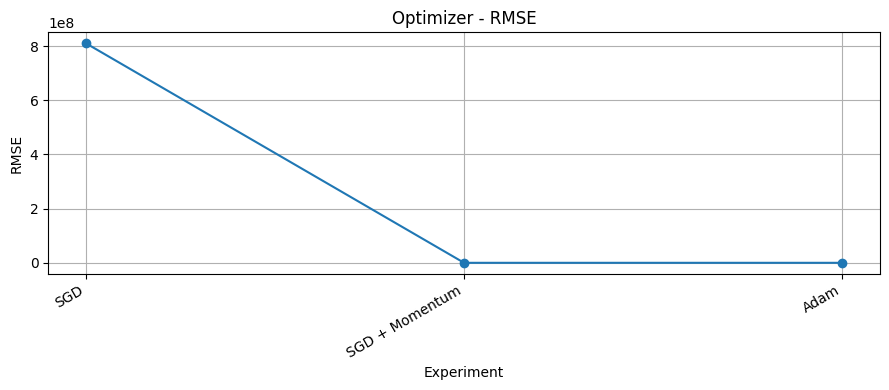

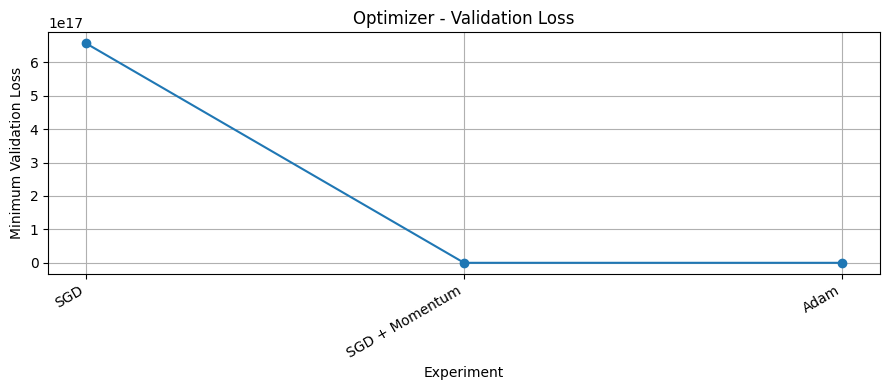

In [ ]:
reg_optimizer_experiments = [
    {
        "experiment": "SGD",
        "model_params": {
            "optimizer_name": "sgd",
            "learning_rate": 0.001
        }
    },
    {
        "experiment": "SGD + Momentum",
        "model_params": {
            "optimizer_name": "sgd_momentum",
            "learning_rate": 0.001,
            "momentum": 0.9
        }
    },
    {
        "experiment": "Adam",
        "model_params": {
            "optimizer_name": "adam",
            "learning_rate": 0.001
        }
    }
]

reg_optimizer_results_df = run_regressor_group_visible(
    group_name="Optimizer",
    experiments=reg_optimizer_experiments,
    default_epochs=10
)

The optimizer controls how the model updates its weights during training.
Adam gave the best regression result with the lowest RMSE (5649), lowest MAE (4354), and highest R² (0.223).
SGD performed very badly with a huge RMSE, while SGD + Momentum was better than SGD but still worse than Adam.

### Regression Learning Rate Effect



Group: Learning Rate
Experiment: LR = 0.0001
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 129888848.0000 - mae: 9520.7695 - val_loss: 131949256.0000 - val_mae: 9570.0283
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 127065976.0000 - mae: 9378.3652 - val_loss: 126661504.0000 - val_mae: 9305.7119
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 118922816.0000 - mae: 8960.0449 - val_loss: 115661416.0000 - val_mae: 8735.3975
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 105530064.0000 - mae: 8239.3916 - val_loss: 100072976.0000 - val_mae: 7883.6602
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 88753480.0000 - mae: 7297.2544 - val_loss: 82345384.0000 - val_mae: 6875.9897
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 71490600.0000 - mae: 6305.2056 - val_loss: 65621088.0000 - val_mae: 5925.4019
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56845308.0000 - mae: 5491.1621 -

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
2,4302.993652,5615.822291,0.231720,Learning Rate,LR = 0.1,31109570.0,10
1,4353.555176,5648.754730,0.222683,Learning Rate,LR = 0.001,31358694.0,10
0,4770.400879,6342.133395,0.020141,Learning Rate,LR = 0.0001,39383564.0,10


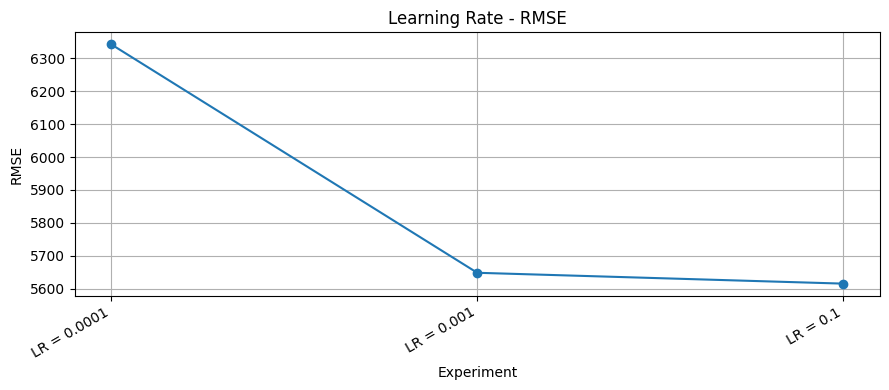

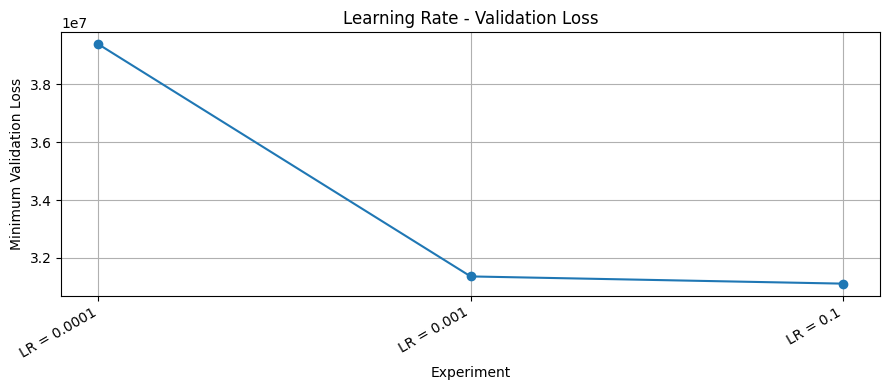

In [ ]:
reg_learning_rate_experiments = [
    {
        "experiment": "LR = 0.0001",
        "model_params": {
            "learning_rate": 0.0001
        }
    },
    {
        "experiment": "LR = 0.001",
        "model_params": {
            "learning_rate": 0.001
        }
    },
    {
        "experiment": "LR = 0.1",
        "model_params": {
            "learning_rate": 0.1
        }
    }
]

reg_learning_rate_results_df = run_regressor_group_visible(
    group_name="Learning Rate",
    experiments=reg_learning_rate_experiments,
    default_epochs=10
)

The learning rate controls how fast the model updates its weights.
LR = 0.1 gave the best regression result with the lowest RMSE (5616), lowest MAE (4303), and highest R² (0.232).
LR = 0.0001 learned too slowly and performed worse, while LR = 0.001 was close but slightly weaker than 0.1.

### Regression Learning Rate Scheduler Effect



Group: Learning Rate Scheduler
Experiment: Without Scheduler
Epochs: 25
Batch size: 32
Epoch 1/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 38561172.0000 - mae: 4723.2344 - val_loss: 31875746.0000 - val_mae: 4326.7480
Epoch 2/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31251362.0000 - mae: 4334.6323 - val_loss: 31751932.0000 - val_mae: 4321.4268
Epoch 3/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 31161166.0000 - mae: 4326.9756 - val_loss: 31665052.0000 - val_mae: 4316.4976
Epoch 4/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31072076.0000 - mae: 4319.1392 - val_loss: 31582240.0000 - val_mae: 4309.8560
Epoch 5/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30977504.0000 - mae: 4311.0508 - val_loss: 31483668.0000 - val_mae: 4301.7397
Epoch 6/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30866636.0000 - mae: 4302.5020 - val_loss: 31350494.0000 - val_mae: 4292.0742
Epoch 7/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30743312.0000 - mae: 429

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
1,4286.258301,5607.197874,0.234078,Learning Rate Scheduler,With Scheduler,30947912.0,25
0,4293.708008,5610.738989,0.233110,Learning Rate Scheduler,Without Scheduler,30973762.0,25


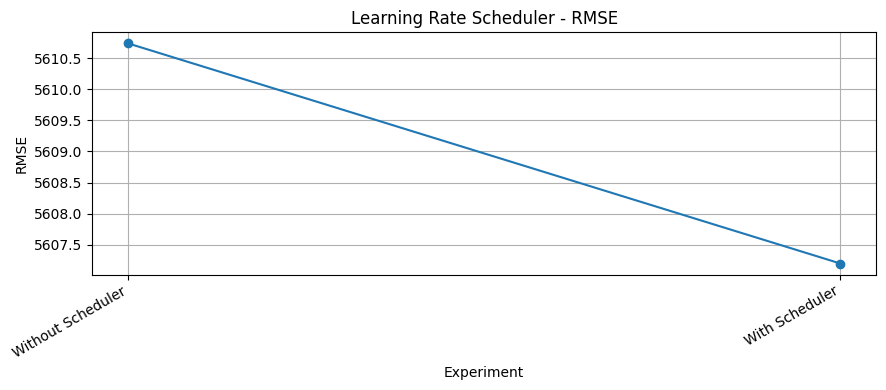

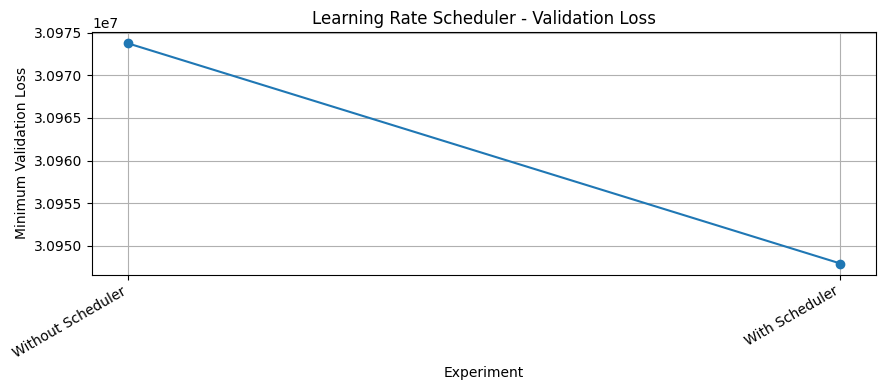

In [ ]:
reg_lr_scheduler_experiments = [
    {
        "experiment": "Without Scheduler",
        "model_params": {
            "learning_rate": 0.01
        },
        "use_scheduler": False
    },
    {
        "experiment": "With Scheduler",
        "model_params": {
            "learning_rate": 0.01
        },
        "use_scheduler": True
    }
]

reg_lr_scheduler_results_df = run_regressor_group_visible(
    group_name="Learning Rate Scheduler",
    experiments=reg_lr_scheduler_experiments,
    default_epochs=25
)


A learning rate scheduler changes the learning rate during training.
Using a scheduler gave a slightly better result with lower RMSE (5607 vs 5611), lower MAE (4286 vs 4294), and higher R² (0.234 vs 0.233).
The improvement is small, but the scheduler helped the regression model converge a little better.

### Regression Batch Size Effect



Group: Batch Size
Experiment: Batch Size = 16
Epochs: 10
Batch size: 16
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 56928140.0000 - mae: 5653.9263 - val_loss: 34848240.0000 - val_mae: 4483.3047
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 33243688.0000 - mae: 4442.3984 - val_loss: 32832748.0000 - val_mae: 4383.1162
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 31966796.0000 - mae: 4375.2773 - val_loss: 31983132.0000 - val_mae: 4341.6611
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 31380542.0000 - mae: 4343.2319 - val_loss: 31617510.0000 - val_mae: 4325.4775
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 31132906.0000 - mae: 4329.2578 - val_loss: 31482954.0000 - val_mae: 4320.3223
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 31035612.0000 - mae: 4323.3643 - val_loss: 31434190.0000 - val_mae: 4318.7515
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 30994786.0000 - mae: 4320

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
0,4343.839844,5647.104037,0.223137,Batch Size,Batch Size = 16,31381070.0,10
1,4353.555176,5648.754730,0.222683,Batch Size,Batch Size = 32,31358694.0,10
2,4455.170410,5780.670203,0.185953,Batch Size,Batch Size = 128,32634320.0,10


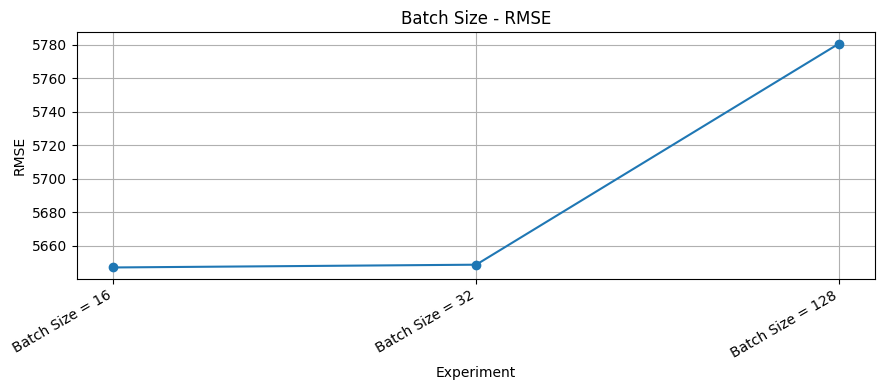

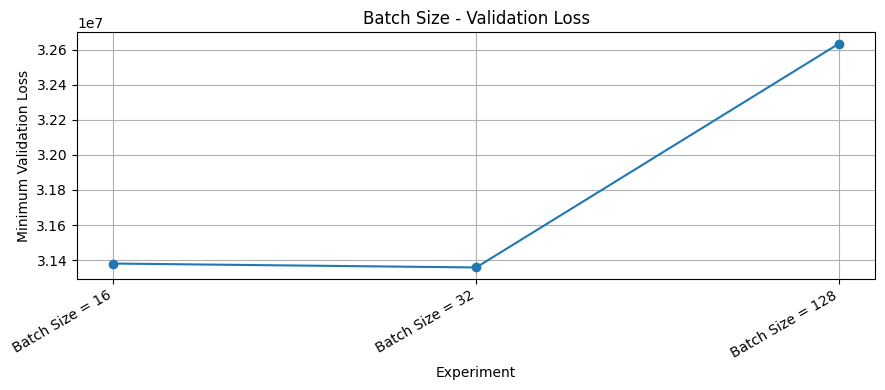

In [ ]:
reg_batch_size_experiments = [
    {
        "experiment": "Batch Size = 16",
        "training_params": {
            "batch_size": 16
        }
    },
    {
        "experiment": "Batch Size = 32",
        "training_params": {
            "batch_size": 32
        }
    },
    {
        "experiment": "Batch Size = 128",
        "training_params": {
            "batch_size": 128
        }
    }
]

reg_batch_size_results_df = run_regressor_group_visible(
    group_name="Batch Size",
    experiments=reg_batch_size_experiments,
    default_epochs=10
)

Changing the batch size affects how many samples the model sees before updating weights.

In this experiment, RMSE increased from 5647.10 with batch size 16 to 5780.67 with batch size 128, and R² decreased from 0.22 to 0.18.

So, smaller batch sizes worked better for this model.

### Regression Number of Epochs Effect



Group: Number of Epochs
Experiment: Epochs = 5
Epochs: 5
Batch size: 32
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407

Final result:
MAE: 4389.2188
RMSE: 5706.224
R2-score: 0.2068
Minimum validation loss: 31845386.0
Epochs used: 5

Group: Number of Epochs
Experiment: Epochs = 10
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - 

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
2,4345.727539,5637.425831,0.225798,Number of Epochs,Epochs = 20,31285678.0,20
1,4353.555176,5648.754730,0.222683,Number of Epochs,Epochs = 10,31358694.0,10
0,4389.218750,5706.223970,0.206786,Number of Epochs,Epochs = 5,31845386.0,5


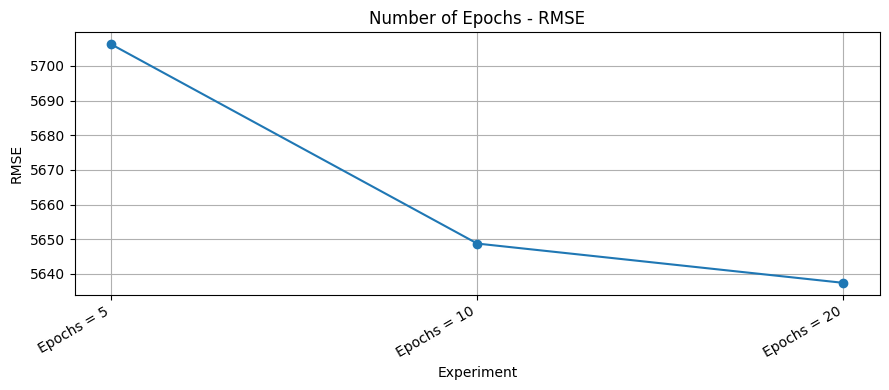

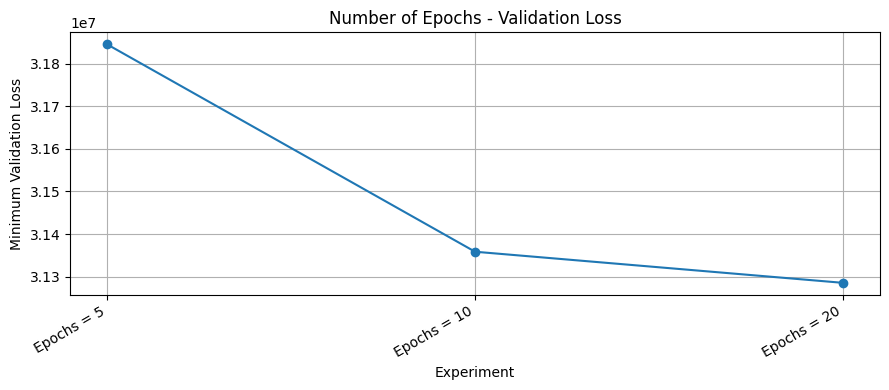

In [ ]:
reg_epoch_experiments = [
    {
        "experiment": "Epochs = 5",
        "training_params": {
            "epochs": 5,
            "batch_size": 32
        },
        "use_early_stopping": False
    },
    {
        "experiment": "Epochs = 10",
        "training_params": {
            "epochs": 10,
            "batch_size": 32
        },
        "use_early_stopping": False
    },
    {
        "experiment": "Epochs = 20",
        "training_params": {
            "epochs": 20,
            "batch_size": 32
        },
        "use_early_stopping": False
    }
]

reg_epoch_results_df = run_regressor_group_visible(
    group_name="Number of Epochs",
    experiments=reg_epoch_experiments,
    default_epochs=10
)

Increasing the number of epochs lets the MLP train longer and learn better patterns.

In this experiment, RMSE decreased from 5706.22 with 5 epochs to 5637.43 with 20 epochs, and R² improved from 0.21 to 0.23.

So, using more epochs improved the model slightly, but the improvement is not very large.

### Regression Width Effect



Group: Width
Experiment: Small Width
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 100170072.0000 - mae: 7922.0234 - val_loss: 48456248.0000 - val_mae: 5073.7446
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 38439740.0000 - mae: 4665.3555 - val_loss: 36444416.0000 - val_mae: 4583.0576
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 34904540.0000 - mae: 4533.0488 - val_loss: 34651264.0000 - val_mae: 4492.1123
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33613596.0000 - mae: 4467.9658 - val_loss: 33604772.0000 - val_mae: 4438.0688
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 32811676.0000 - mae: 4425.0811 - val_loss: 32896088.0000 - val_mae: 4401.8784
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 32247860.0000 - mae: 4393.8882 - val_loss: 32388742.0000 - val_mae: 4376.6226
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31841162.0000 - mae: 4370.9976 - val_loss: 3202

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
2,4343.216797,5646.516448,0.223299,Width,Large Width,31378278.0,10
1,4353.555176,5648.754730,0.222683,Width,Medium Width,31358694.0,10
0,4373.878418,5668.209947,0.217319,Width,Small Width,31501642.0,10


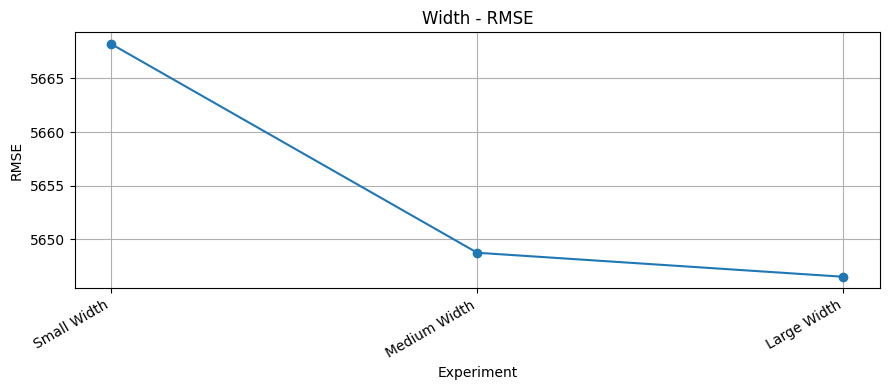

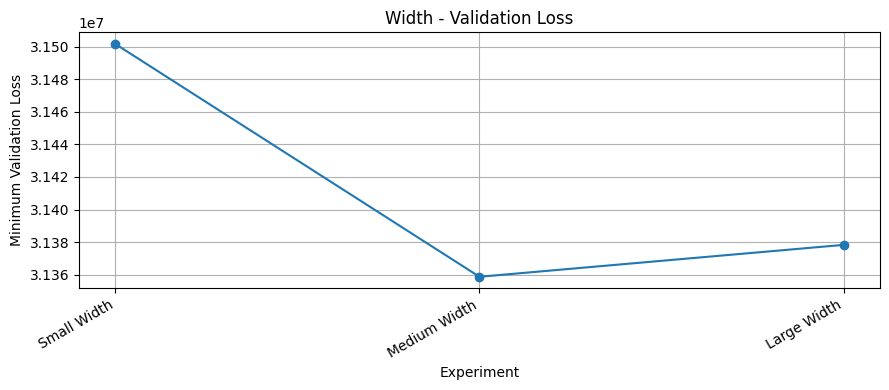

In [ ]:
reg_width_experiments = [
    {
        "experiment": "Small Width",
        "model_params": {
            "no_hidden_neurons": [32, 16]
        }
    },
    {
        "experiment": "Medium Width",
        "model_params": {
            "no_hidden_neurons": [64, 32]
        }
    },
    {
        "experiment": "Large Width",
        "model_params": {
            "no_hidden_neurons": [128, 64]
        }
    }
]

reg_width_results_df = run_regressor_group_visible(
    group_name="Width",
    experiments=reg_width_experiments,
    default_epochs=10
)

Width is the number of neurons in each hidden layer.
Large Width gave the best regression result with the lowest RMSE (5647) and highest R² (0.223).
Small Width performed worse, so a wider model helped the MLP learn better.

### Regression Depth Effect



Group: Depth
Experiment: 1 Hidden Layer
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 126854488.0000 - mae: 9370.7070 - val_loss: 123161192.0000 - val_mae: 9139.3496
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 109743656.0000 - mae: 8489.1602 - val_loss: 100455168.0000 - val_mae: 7939.6514
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 85608576.0000 - mae: 7153.8613 - val_loss: 76090536.0000 - val_mae: 6554.6797
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 64062904.0000 - mae: 5919.0469 - val_loss: 57367940.0000 - val_mae: 5518.4302
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 49724912.0000 - mae: 5138.5366 - val_loss: 46408012.0000 - val_mae: 4976.3794
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 42386936.0000 - mae: 4801.7939 - val_loss: 41304684.0000 - val_mae: 4773.5312
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 39201272.0000 - mae: 4691.0454 - val_loss

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
2,4312.228516,5642.463469,0.224413,Depth,3 Hidden Layers,31337888.0,10
1,4353.555176,5648.754730,0.222683,Depth,2 Hidden Layers,31358694.0,10
0,4620.340332,6055.614915,0.106675,Depth,1 Hidden Layer,35900256.0,10


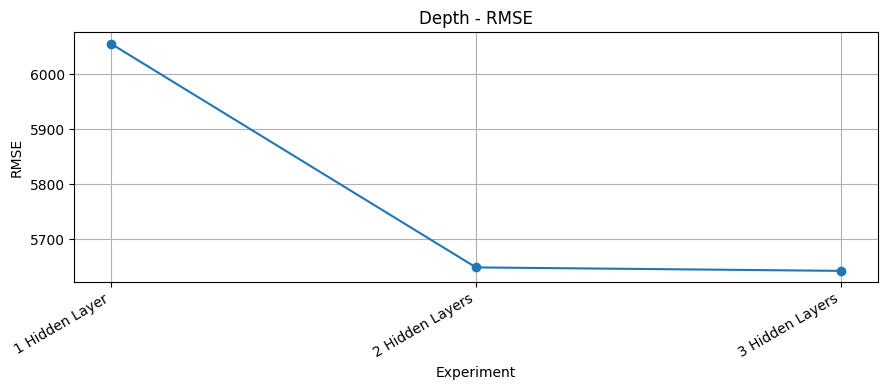

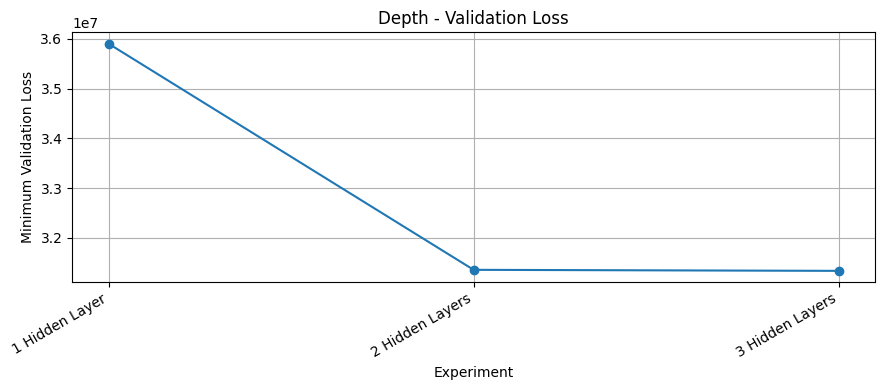

In [ ]:
reg_depth_experiments = [
    {
        "experiment": "1 Hidden Layer",
        "model_params": {
            "no_hidden_neurons": [64]
        }
    },
    {
        "experiment": "2 Hidden Layers",
        "model_params": {
            "no_hidden_neurons": [64, 32]
        }
    },
    {
        "experiment": "3 Hidden Layers",
        "model_params": {
            "no_hidden_neurons": [128, 64, 32]
        }
    }
]

reg_depth_results_df = run_regressor_group_visible(
    group_name="Depth",
    experiments=reg_depth_experiments,
    default_epochs=10
)

Increasing the number of hidden layers can help the MLP learn more complex patterns.

In this experiment, RMSE decreased from 6055.61 with 1 hidden layer to 5642.46 with 3 hidden layers, and R² improved from 0.11 to 0.22.

So, using more hidden layers improved the model, but the change from 2 to 3 layers was very small.

### Regression Activation Function Effect



Group: Activation Function
Experiment: ReLU
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31168810.0000 - mae: 4331.1602 - val_loss

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
1,4353.679199,5648.715783,0.222694,Activation Function,LeakyReLU,31358484.0,10
0,4353.555176,5648.754730,0.222683,Activation Function,ReLU,31358694.0,10
2,9393.676758,11370.603150,-2.149632,Activation Function,Tanh,127492936.0,10
3,9458.168945,11423.940126,-2.179250,Activation Function,Sigmoid,128700840.0,10


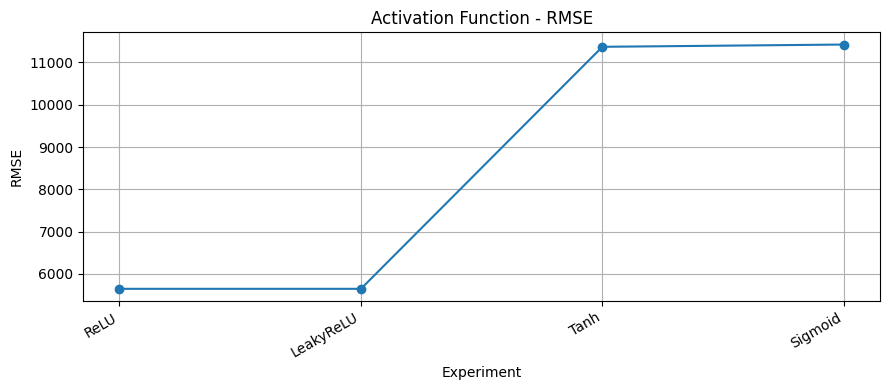

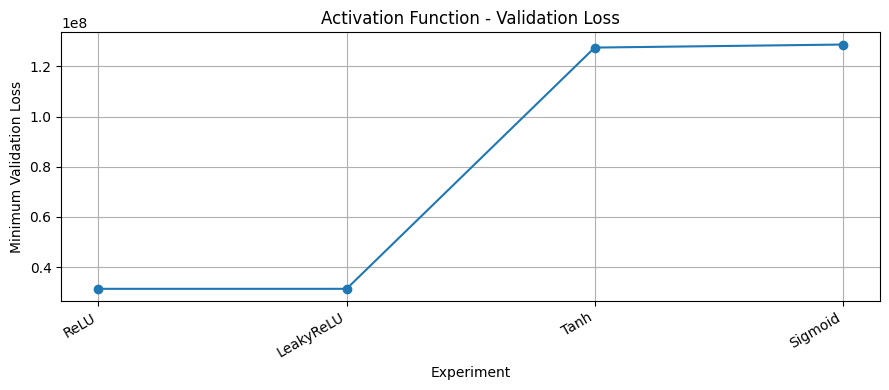

In [ ]:
reg_activation_experiments = [
    {
        "experiment": "ReLU",
        "model_params": {
            "activation_func": "relu"
        }
    },
    {
        "experiment": "LeakyReLU",
        "model_params": {
            "activation_func": "leaky_relu"
        }
    },
    {
        "experiment": "Tanh",
        "model_params": {
            "activation_func": "tanh"
        }
    },
    {
        "experiment": "Sigmoid",
        "model_params": {
            "activation_func": "sigmoid"
        }
    }
]

reg_activation_results_df = run_regressor_group_visible(
    group_name="Activation Function",
    experiments=reg_activation_experiments,
    default_epochs=10
)

The activation function changes how neurons output signals and affects learning.

In this experiment, ReLU and LeakyReLU gave similar RMSE around 5648, while Tanh and Sigmoid had much higher RMSE over 11370 and negative R².

So, ReLU or LeakyReLU worked best for this model.

### Regression Weight Initialization Effect



Group: Weight Initialization
Experiment: Glorot Uniform
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31168810.0000 - mae: 4331.160

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
1,4353.729492,5648.444211,0.222768,Weight Initialization,He Normal,31344382.0,10
0,4353.555176,5648.754730,0.222683,Weight Initialization,Glorot Uniform,31358694.0,10
2,4355.533691,5649.829555,0.222387,Weight Initialization,Random Normal,31377754.0,10
3,9670.229492,11600.119310,-2.278066,Weight Initialization,Zeros,132731320.0,10


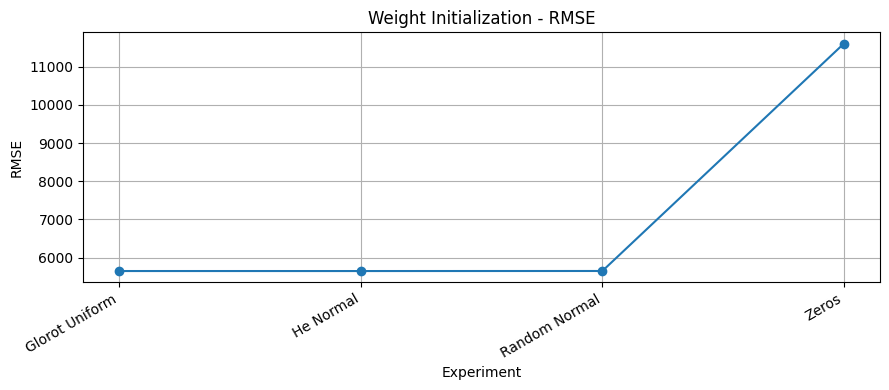

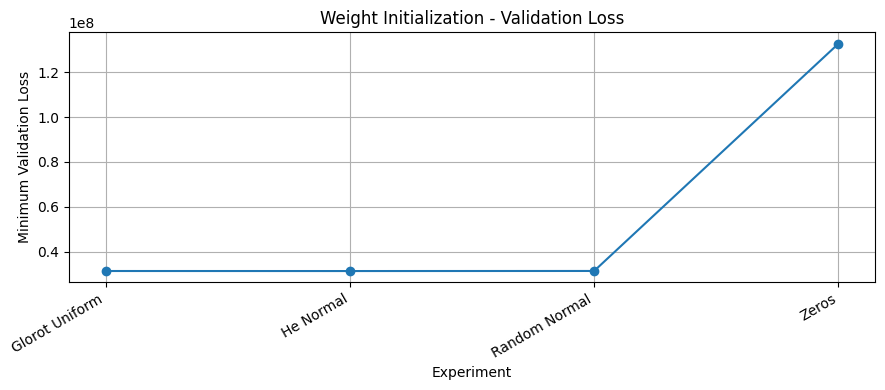

In [ ]:
reg_initialization_experiments = [
    {
        "experiment": "Glorot Uniform",
        "model_params": {
            "weight_initializer": "GlorotUniform"
        }
    },
    {
        "experiment": "He Normal",
        "model_params": {
            "weight_initializer": "HeNormal"
        }
    },
    {
        "experiment": "Random Normal",
        "model_params": {
            "weight_initializer": "RandomNormal"
        }
    },
    {
        "experiment": "Zeros",
        "model_params": {
            "weight_initializer": "Zeros"
        }
    }
]

reg_initialization_results_df = run_regressor_group_visible(
    group_name="Weight Initialization",
    experiments=reg_initialization_experiments,
    default_epochs=10
)

Weight initialization sets the starting values of model weights and affects learning stability.

In this experiment, He Normal, Glorot Uniform, and Random Normal gave similar RMSE around 5648, but initializing with Zeros caused RMSE to jump to 11600 and R² to drop below -2.

So, proper weight initialization like He Normal or Glorot Uniform is important for good performance.

### Regression Batch Normalization Effect



Group: Batch Normalization
Experiment: Without BatchNorm
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31168810.0000 - mae: 4331.16

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
0,4353.555176,5648.754730,0.222683,Batch Normalization,Without BatchNorm,31358694.0,10
1,6772.313477,8521.032801,-0.768794,Batch Normalization,With BatchNorm,72241024.0,10


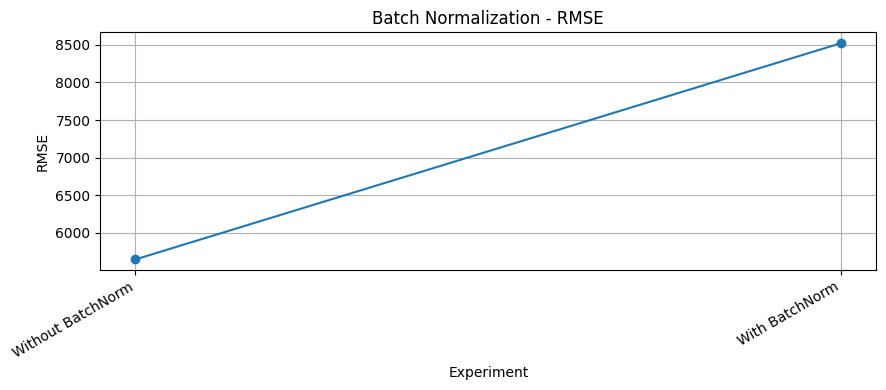

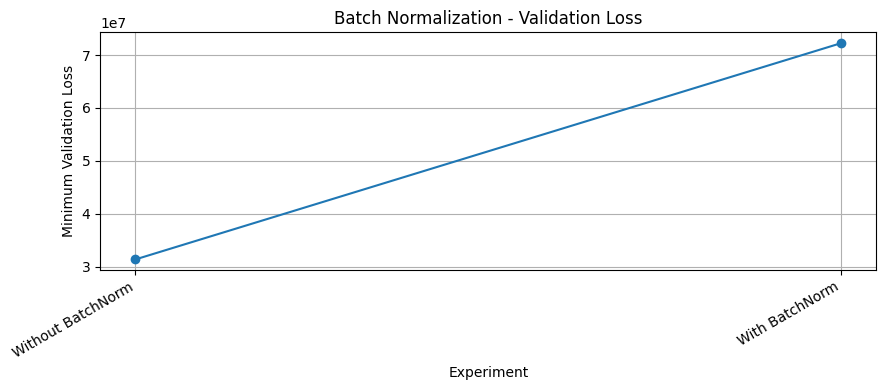

In [ ]:
reg_batch_norm_experiments = [
    {
        "experiment": "Without BatchNorm",
        "model_params": {
            "use_batch_norm": False
        }
    },
    {
        "experiment": "With BatchNorm",
        "model_params": {
            "use_batch_norm": True
        }
    }
]

reg_batch_norm_results_df = run_regressor_group_visible(
    group_name="Batch Normalization",
    experiments=reg_batch_norm_experiments,
    default_epochs=10
)

Batch Normalization standardizes layer inputs to improve training speed and stability.

In this experiment, adding BatchNorm increased RMSE from 5648.75 to 8521.03 and decreased R² from 0.22 to -0.77.

So, for this model, Batch Normalization actually worsened performance.

### Regression L1 and L2 Regularization Effect



Group: L1 and L2 Regularization
Experiment: No Regularization
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31168810.0000 - mae: 43

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
1,4353.554688,5648.729946,0.222690,L1 and L2 Regularization,L1 = 0.001,31358434.0,10
3,4353.568359,5648.735611,0.222688,L1 and L2 Regularization,"L1 = 0.0001, L2 = 0.001",31358590.0,10
2,4353.588867,5648.747472,0.222685,L1 and L2 Regularization,L2 = 0.001,31358774.0,10
0,4353.555176,5648.754730,0.222683,L1 and L2 Regularization,No Regularization,31358694.0,10


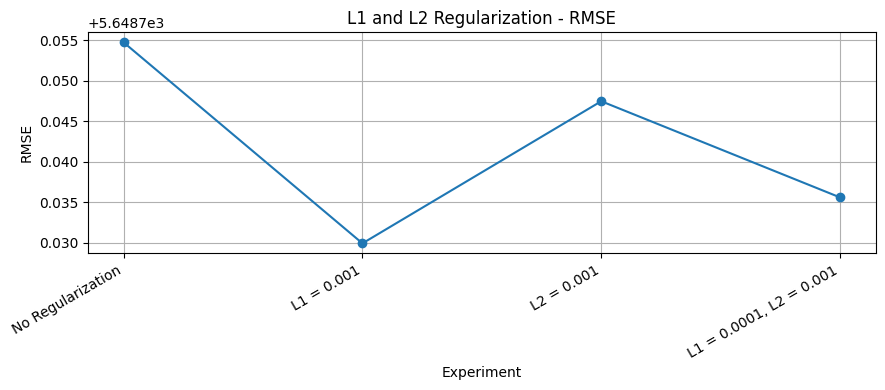

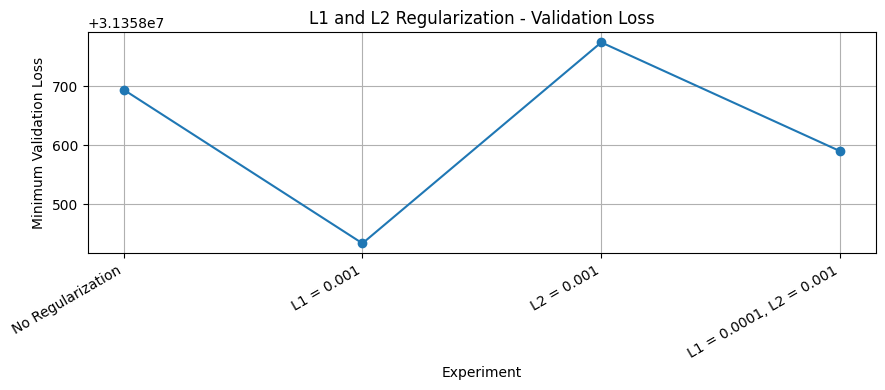

In [ ]:
reg_regularization_experiments = [
    {
        "experiment": "No Regularization",
        "model_params": {
            "l1_reg": 0.0,
            "l2_reg": 0.0
        }
    },
    {
        "experiment": "L1 = 0.001",
        "model_params": {
            "l1_reg": 0.001,
            "l2_reg": 0.0
        }
    },
    {
        "experiment": "L2 = 0.001",
        "model_params": {
            "l1_reg": 0.0,
            "l2_reg": 0.001
        }
    },
    {
        "experiment": "L1 = 0.0001, L2 = 0.001",
        "model_params": {
            "l1_reg": 0.0001,
            "l2_reg": 0.001
        }
    }
]

reg_regularization_results_df = run_regressor_group_visible(
    group_name="L1 and L2 Regularization",
    experiments=reg_regularization_experiments,
    default_epochs=10
)

L1 and L2 regularization help reduce overfitting by adding a penalty to large weights.

In this experiment, the RMSE values were almost the same, but L1 = 0.001 gave the lowest RMSE at 5648.73.

So, regularization had a very small effect, and L1 performed slightly better.

### Regression Activity Regularization Effect



Group: Activity Regularization
Experiment: No Activity Regularization
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31168810.0000 -

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
2,4352.847168,5648.749419,0.222684,Activity Regularization,Activity L2 = 0.001,31440824.0,10
0,4353.555176,5648.754730,0.222683,Activity Regularization,No Activity Regularization,31358694.0,10
1,4353.566895,5648.772787,0.222678,Activity Regularization,Activity L1 = 0.001,31359176.0,10


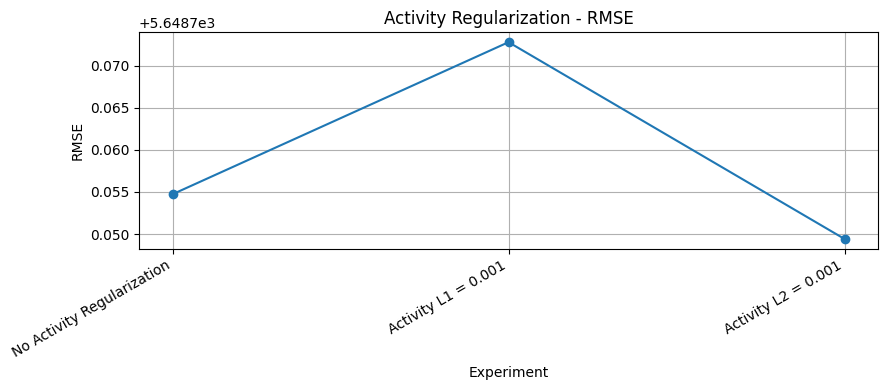

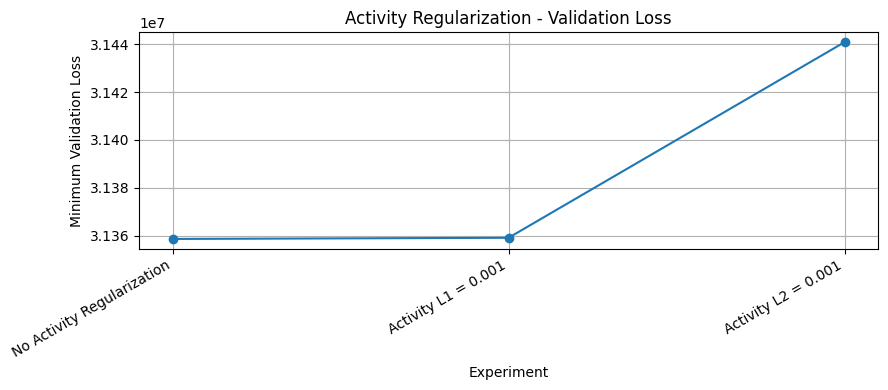

In [43]:
reg_activity_regularization_experiments = [
    {
        "experiment": "No Activity Regularization",
        "model_params": {
            "activity_l1_reg": 0.0,
            "activity_l2_reg": 0.0
        }
    },
    {
        "experiment": "Activity L1 = 0.001",
        "model_params": {
            "activity_l1_reg": 0.001,
            "activity_l2_reg": 0.0
        }
    },
    {
        "experiment": "Activity L2 = 0.001",
        "model_params": {
            "activity_l1_reg": 0.0,
            "activity_l2_reg": 0.001
        }
    }
]

reg_activity_regularization_results_df = run_regressor_group_visible(
    group_name="Activity Regularization",
    experiments=reg_activity_regularization_experiments,
    default_epochs=10
)

Write your observation here after running this cell. Mention whether penalizing neuron outputs helps or hurts regression performance.


### Regression Dropout Effect



Group: Dropout
Experiment: No Dropout
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 31168810.0000 - mae: 4331.1602 - val_loss: 3147

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
0,4353.555176,5648.754730,0.222683,Dropout,No Dropout,31358694.0,10
1,4346.666016,5658.180626,0.220086,Dropout,Dropout = 0.2,31450448.0,10
2,4337.233887,5681.943682,0.213522,Dropout,Dropout = 0.4,31686962.0,10


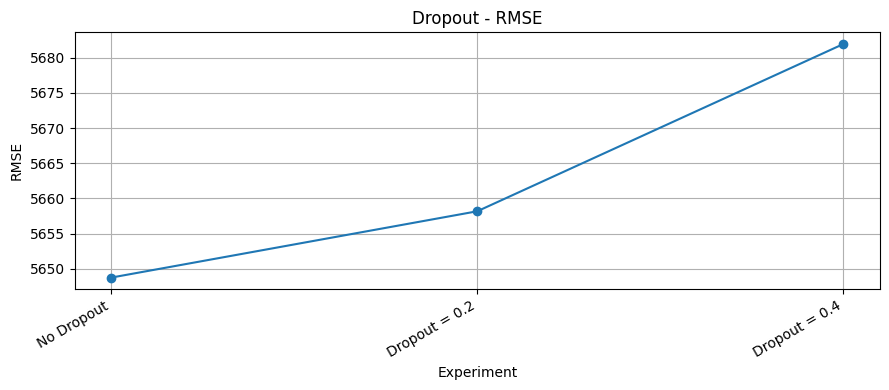

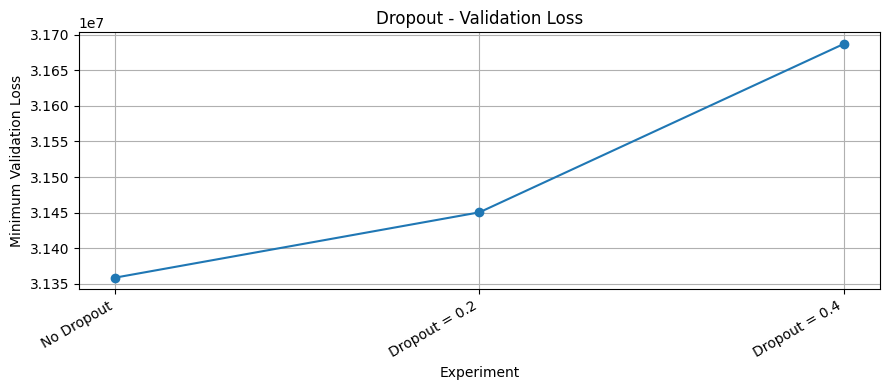

In [ ]:
reg_dropout_experiments = [
    {
        "experiment": "No Dropout",
        "model_params": {
            "dropout_rate": 0.0
        }
    },
    {
        "experiment": "Dropout = 0.2",
        "model_params": {
            "dropout_rate": 0.2
        }
    },
    {
        "experiment": "Dropout = 0.4",
        "model_params": {
            "dropout_rate": 0.4
        }
    }
]

reg_dropout_results_df = run_regressor_group_visible(
    group_name="Dropout",
    experiments=reg_dropout_experiments,
    default_epochs=10
)

Dropout randomly ignores neurons during training to prevent overfitting.

In this experiment, using dropout increased RMSE from 5648.75 (No Dropout) to 5681.94 with dropout 0.4, and R² decreased from 0.22 to 0.21.

So, dropout slightly worsened performance for this model.

### Regression Gradient Clipping Effect



Group: Gradient Clipping
Experiment: No Clipping
Epochs: 10
Batch size: 32
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 77173248.0000 - mae: 6685.9131 - val_loss: 37863520.0000 - val_mae: 4645.0908
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35208468.0000 - mae: 4541.9751 - val_loss: 34364812.0000 - val_mae: 4468.2993
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 33222448.0000 - mae: 4443.4375 - val_loss: 33035008.0000 - val_mae: 4402.3203
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 32269210.0000 - mae: 4392.7524 - val_loss: 32284520.0000 - val_mae: 4365.5801
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31694724.0000 - mae: 4361.4126 - val_loss: 31845386.0000 - val_mae: 4344.7407
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31356588.0000 - mae: 4342.1987 - val_loss: 31601806.0000 - val_mae: 4333.5845
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31168810.0000 - mae: 4331.1602 - val

,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
0,4353.555176,5648.754730,0.222683,Gradient Clipping,No Clipping,31358694.0,10
1,4343.270508,5658.722294,0.219937,Gradient Clipping,Clipnorm = 1,31423366.0,10


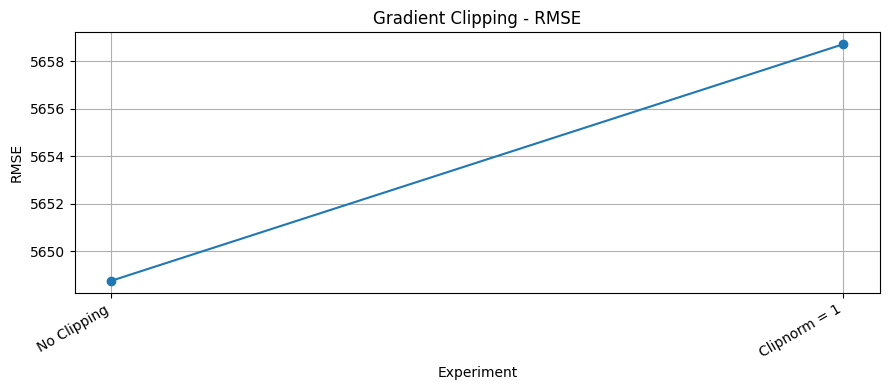

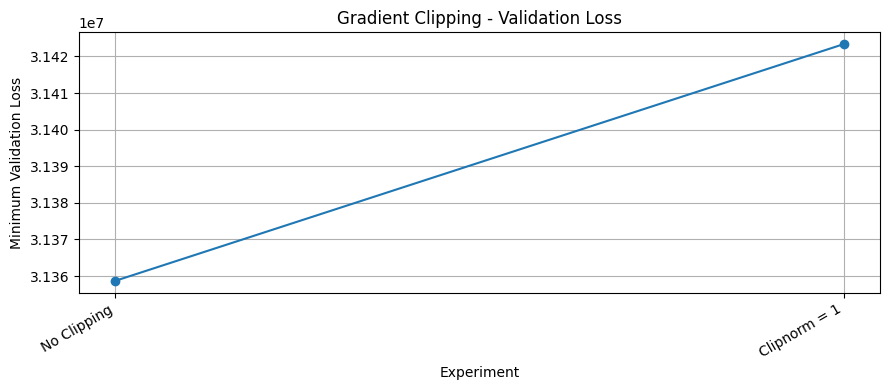

In [44]:
reg_gradient_clipping_experiments = [
    {
        "experiment": "No Clipping",
        "model_params": {
            "clipnorm": None
        }
    },
    {
        "experiment": "Clipnorm = 1",
        "model_params": {
            "clipnorm": 1.0
        }
    }
]

reg_gradient_clipping_results_df = run_regressor_group_visible(
    group_name="Gradient Clipping",
    experiments=reg_gradient_clipping_experiments,
    default_epochs=10
)

Gradient clipping limits the size of gradients during training to prevent exploding gradients.

In this experiment, using Clipnorm = 1 slightly increased RMSE from 5648.75 to 5658.72 and decreased R² from 0.2227 to 0.2199.

So, gradient clipping had a very small negative effect on this model.

### Final Regression Experiment Summary


In [47]:
# Combine all regression results.
reg_results_df = pd.concat(regression_result_tables.values(), ignore_index=True)

# Sort by RMSE for display. Lower RMSE is better.
display(
    reg_results_df.sort_values(
        ["rmse", "mae", "r2"],
        ascending=[True, True, False]
    )
)





,mae,rmse,r2,group,experiment,min_val_loss,epochs_used
8,4.286258e+03,5.607198e+03,2.340779e-01,Learning Rate Scheduler,With Scheduler,3.094791e+07,25
7,4.293708e+03,5.610739e+03,2.331102e-01,Learning Rate Scheduler,Without Scheduler,3.097376e+07,25
6,4.302994e+03,5.615822e+03,2.317200e-01,Learning Rate,LR = 0.1,3.110957e+07,10
0,4.338316e+03,5.629816e+03,2.278863e-01,Baseline,Baseline,3.120728e+07,30
14,4.345728e+03,5.637426e+03,2.257976e-01,Number of Epochs,Epochs = 20,3.128568e+07,20
20,4.312229e+03,5.642463e+03,2.244133e-01,Depth,3 Hidden Layers,3.133789e+07,10
17,4.343217e+03,5.646516e+03,2.232987e-01,Width,Large Width,3.137828e+07,10
9,4.343840e+03,5.647104e+03,2.231371e-01,Batch Size,Batch Size = 16,3.138107e+07,10
26,4.353729e+03,5.648444e+03,2.227683e-01,Weight Initialization,He Normal,3.134438e+07,10
22,4.353679e+03,5.648716e+03,2.226936e-01,Activation Function,LeakyReLU,3.135848e+07,10


## MLP Discussion Questions

### 1. Why are neural networks so powerful?

Neural networks are powerful because they can model complex and nonlinear relationships between input features and output targets. Unlike simple linear models, an MLP uses hidden layers and nonlinear activation functions to learn patterns that may not be directly visible in the original feature space.

One important reason is the **Universal Approximation Theorem**, which states that a neural network with at least one hidden layer and enough neurons can approximate a very wide range of continuous functions. This means that neural networks are flexible enough to learn complicated mappings for both classification and regression problems.

Another reason is that neural networks can perform a form of automatic feature learning. Instead of relying only on manually designed features, each hidden layer transforms the input into a more useful representation. Lower layers may learn simple relationships, while deeper layers can combine them into more abstract patterns.

In this assignment, MLPs are useful because the dataset contains several numerical and encoded categorical features. A neural network can combine these features in nonlinear ways, which may help capture interactions that simpler models might miss.

---

### 2. Why does training become more difficult as we go deeper?

Training becomes more difficult as the number of hidden layers increases because the model becomes more complex and optimization becomes harder. In deep networks, gradients must be passed backward through many layers during backpropagation. As they move through the layers, they can become extremely small or extremely large. These problems are known as **vanishing gradients** and **exploding gradients**.

When gradients vanish, earlier layers learn very slowly because their weights receive only tiny updates. When gradients explode, training becomes unstable and the loss may fluctuate heavily or even become NaN. This is one reason why deeper models often require careful choices of learning rate, activation function, weight initialization, normalization, and regularization.

Deeper networks also have more parameters, so they are more likely to overfit if the dataset is not large enough. They can memorize the training data instead of learning patterns that generalize well to unseen data. This is why techniques such as early stopping, dropout, L1/L2 regularization, batch normalization, and learning rate scheduling are important.

In my experiments, deeper or wider models did not automatically guarantee better performance. In some cases, they improved training performance but not validation or test performance, which suggests overfitting or unstable optimization.

---

### 3. If MLPs can approximate any function with a single hidden layer, what unique benefits does depth provide?

Although a sufficiently wide single-hidden-layer network can theoretically approximate many functions, using depth can be much more efficient in practice. A very wide shallow network may need a huge number of neurons to represent a complex function, while a deeper network can represent the same function using fewer parameters.

Depth allows neural networks to learn **hierarchical representations**. Each layer builds on the output of the previous layer. Early layers can learn simple patterns, and later layers can combine them into more complex and abstract patterns. This layered structure is especially useful when the target depends on combinations or interactions between several features.

For example, in tabular data, one layer may learn simple relations between income, loan amount, interest rate, or credit score. Later layers may combine these learned relations into more useful representations for predicting the final classification or regression target.

Therefore, depth is not only about increasing model capacity. It changes how the network organizes and reuses information. However, depth must be used carefully because very deep networks can be harder to train and may overfit without enough data or regularization.
